# Does citing a concept "as your own" predict its spread? — the naturalisation-gap screen (candidate L)

This notebook is a runnable demo of the experiment script `method.py` (plus the helper modules it imports:
`panel.py`, `s0.py`, `lineage.py`, `pool.py`, `screen.py`). The code is the original code, split into cells, with
explanations added between the sections.

**What it tests.** Take a research concept (e.g. *compressed sensing*, *optogenetics*). Its early papers (years
t0..t0+4) cite each other. When a paper from an *off-home* field j cites an earlier concept paper, is that parent
more likely to come from field j as well (the concept is being "naturalised" in j) than from the concept's home
field H? The candidate feature is **A\*_h**, a *background-adjusted naturalisation gap*:

1. **Stage 1.** For each concept × off-home field j, compute a year-stratified Mantel–Haenszel log odds ratio
   (child in j vs H) × (parent in j vs H). Subtract the same log-OR computed on the *same children's background
   reference lists*, which removes plain field homophily. Get a variance from a child bootstrap.
2. **Stage 2.** Pool these ρ̂_cj with a crossed random-effects model fitted by REML (concept effect τ_c, cell effect
   τ_cj). Then A\*_h = Σ_j π_cj ρ\*_cj.
3. **Screen.** Does A\*_h improve on the common 5-feature count baseline **B5** (early volume, growth, off-home
   share, field entropy, number of fields)? The outcome is later field breadth **O2r**, evaluated under
   leave-one-field-group-out (LOGO) ridge prediction. The pre-registered survival rule has four clauses:
   Δρ ≥ 0.10 with CI low > 0, at least 3 of 4 groups positive, split-half reliability ≥ 0.6, and |ρ| with size ≤ 0.6.

**Headline of the original full run (48 dev concepts): A\*_h does NOT survive.** Δρ = −0.006, 90% CI
[−0.034, 0.017]; 0 of 4 groups are positive; reliability is 0.58.

**Demo data.** `mini_demo_data.json` holds the full S0 yearly-count file for all 78 panel concepts. It also holds
the Semantic Scholar concept papers, citation lineage and background references for **18 of the 48** dev concepts
(all four field groups), trimmed to the keys the code reads. The other concepts follow the original
"not fetched" drop path. With 18 concepts the numbers are noisier than the full run's. The final cell compares
them with the full-run reference values stored in the data file.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT on Colab, always install
_pip('loguru==0.7.3')

# numpy, pandas, scipy, scikit-learn, statsmodels, matplotlib — pre-installed on Colab, install locally only
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scipy==1.16.3', 'scikit-learn==1.6.1', 'statsmodels==0.14.6',
         'matplotlib==3.10.0')

# pymc — used only by the optional PyMC NUTS check (config NO_PYMC); Colab usually ships it, install only if missing
try:
    import pymc  # noqa: F401
except ImportError:
    _pip('pymc==6.3.2')

## Imports

This is the original import block of `method.py`. The five helper modules it imported (`lineage`, `panel`, `pool`,
`s0`, `screen`) are defined inline in the cells below, each with its own import lines.

In [2]:
import os

for _v in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS"):  # small matrices: avoid BLAS oversubscription
    os.environ.setdefault(_v, "1")

import argparse
import gzip
import json
import math
import multiprocessing as mp
import pickle
import resource
import sys
import time
from concurrent.futures import ProcessPoolExecutor
from pathlib import Path

import numpy as np
import pandas as pd
from loguru import logger
from scipy.stats import spearmanr
import argparse  # notebook: config namespace replaces the CLI
import matplotlib.pyplot as plt

## Data loading
The data comes from GitHub, with a fallback to a local `mini_demo_data.json`.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-8795ea-concepts-spread-once-adopters-make-them/fork/run_DVtwwCx0JbFq/round-1/experiment-1/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(f"{len(data['concepts'])} concepts with S2 lineage data:", data["concept_names"])
print(f"S0 yearly counts for {len([k for k in data['s0_raw'] if not k.startswith('_')])} panel concepts")

18 concepts with S2 lineage data: ['zinc finger nuclease', 'sirtuin', 'human microbiome', 'piRNA', 'interactome', 'ribotype 027', 'takotsubo cardiomyopathy', 'single-incision laparoscopic surgery', 'natural orifice transluminal endoscopic surgery', 'patient-centered medical home', 'internet of things', 'social tagging', 'learning to rank', 'latent Dirichlet allocation', 'folksonomy', 'cloud computing', 'wireless body area network', 'energy harvesting']
S0 yearly counts for 78 panel concepts


## Config

These values replace the original command-line arguments of `method.py`
(`--max-concepts`, `--splits`, `--n-boot`, `--no-pymc`, `--no-glmm`, `--workers`).
On the 18-concept demo subset, the **original full-run values** (50 splits, 2000 bootstraps, PyMC and GLMM
checks on) finish in about 2 minutes of compute, plus about 1 minute for the install. For a quicker look, lower
`SPLITS` / `N_BOOT` or set `NO_PYMC = True`.

In [5]:
# Original full-run values: python method.py --splits 50 --n-boot 2000 (all other flags at their defaults)
MAX_CONCEPTS = 10**6   # original: 10**6 (no cap: every dev concept in the data)
SPLITS = 50            # original: 50 split-half replicates for reliability
N_BOOT = 2000          # original: 2000 concept-bootstrap resamples for every Delta-rho / Delta-AUC CI
NO_PYMC = False        # original: False (PyMC NUTS headline check; set True to skip it and save time)
NO_GLMM = False        # original: False (one-stage BinomialBayesMixedGLM robustness check)
WORKERS = 1            # original: 4 (process pool); the notebook runs the splits in-process
PYMC_DRAWS = 1000      # original: 1000 draws (+1000 tune)
PYMC_CHAINS = 4        # original: 4 chains

args = argparse.Namespace(max_concepts=MAX_CONCEPTS, splits=SPLITS, n_boot=N_BOOT, no_pymc=NO_PYMC, no_glmm=NO_GLMM,
                          workers=WORKERS, pymc_draws=PYMC_DRAWS, pymc_chains=PYMC_CHAINS)
print(args)

Namespace(max_concepts=1000000, splits=50, n_boot=2000, no_pymc=False, no_glmm=False, workers=1, pymc_draws=1000, pymc_chains=4)


## Helper module `panel.py`: the frozen P78 panel

There are 78 concepts in 4 field groups. They are processed in an order seeded with 20260928.

In [6]:
"""Frozen screen panel P78 (identical in every screen artifact) and the seeded processing order."""
from __future__ import annotations

import random

GROUPS = {
    "CS/AI": "extreme learning machine; compressed sensing/compressive sensing; crowdsourcing; cloud computing; deep belief network; dictionary learning; folksonomy; social tagging; Web 2.0; mashup; service-oriented architecture; MapReduce; NoSQL; cognitive radio; network coding; vehicular ad hoc network/VANET; wireless body area network; internet of things; cyber-physical system; sentiment analysis; latent Dirichlet allocation; differential privacy; learning to rank; microblog",
    "Engineering": "smart grid; microgrid; vehicle-to-grid; plug-in hybrid electric vehicle; energy harvesting; microbial fuel cell; carbon capture and storage; WiMAX; ZigBee; LTE-Advanced; virtual power plant; piezoelectric nanogenerator; memristor; ultra-wideband; demand response; structural health monitoring",
    "Biochem/Genetics": "induced pluripotent stem cell; optogenetics; ChIP-seq; RNA-seq; next-generation sequencing; copy number variation; genome-wide association study/GWAS; exome sequencing; long noncoding RNA/lncRNA; piRNA; synthetic biology; metagenomics; human microbiome; cancer stem cell; zinc finger nuclease; lipidomics; interactome; DNA barcoding; sirtuin; nanopore sequencing",
    "Medicine": "severe acute respiratory syndrome/SARS coronavirus; H5N1; pandemic H1N1/swine flu; transcatheter aortic valve implantation/TAVI; natural orifice transluminal endoscopic surgery/NOTES; single-incision laparoscopic surgery; drug-eluting stent; cardiac resynchronization therapy; HPV vaccine; biosimilar; pay for performance; comparative effectiveness research; patient-centered medical home; ribotype 027; chronic traumatic encephalopathy; mHealth; capsule endoscopy; takotsubo cardiomyopathy",
}

# aliases that are common English words when lower-cased: never sent to the (case-insensitive) search filter
NOT_SEARCHED = {"NOTES"}
ACRONYMS = {"GWAS", "VANET", "lncRNA", "TAVI", "SARS coronavirus", "NOTES"}
SEED = 20260928
DEV_FIELDS = ["Computer Science", "Engineering", "Biochemistry, Genetics and Molecular Biology", "Medicine"]


def panel() -> list[dict]:
    out = []
    for g, s in GROUPS.items():
        for item in s.split(";"):
            names = [x.strip() for x in item.split("/")]
            out.append({"canonical": names[0], "aliases": names, "panel_group": g})
    assert len(out) == 78, len(out)
    return out


def seeded_order() -> list[dict]:
    order = panel()[:]
    random.Random(SEED).shuffle(order)
    return order


def slug(name: str) -> str:
    return "".join(ch if ch.isalnum() else "_" for ch in name.lower()).strip("_")


def search_filter(c: dict) -> str:
    phrases = [a for a in c["aliases"] if a not in NOT_SEARCHED]
    return "title_and_abstract.search:" + "|".join(f'"{p}"' for p in phrases)


BASE_FILTER = "type:article|review,is_paratext:false"

## Helper module `s0.py`: shared screen protocol S0

This module defines the onset t0 (first year with ≥ 20 papers), the *newborn* flag, the home field, the exact
rarefied richness (Hurlbert 1971) used for the breadth outcome **O2r** (m = 30), Shannon entropy, and
`compute_s0` for the OpenAlex topic-field version of S0.
*Notebook change:* the OpenAlex API pull functions (`yearly`, `global_counts`, `field_counts`, `fetch_s0`) and
their `oa` client import are left out. They only fetch raw data, and the demo loads that data from
`mini_demo_data.json` instead.

In [7]:
"""Shared screen protocol S0: onset, newborn flag, home field, dev restriction, outcomes O1/O2r/O3, R_j, B5.

Credit-bound deviation D8 (documented): field labels for S0 (home, early/late field distributions, B5, O2r, R_j)
come from ONE group_by=primary_topic.field.id call per window (1 credit) instead of source group_by + venue
labelling of every source (hundreds of credits per concept). The candidate lineage feature keeps VENUE labels,
so outcome labels and feature labels come from different label systems (no shared-measurement leakage).
"""
from __future__ import annotations

import math
from concurrent.futures import ThreadPoolExecutor

import numpy as np
from loguru import logger
from scipy.special import gammaln


FIELD_GB = "primary_topic.field.id"


def onset(yc: dict[int, int]) -> int | None:
    ys = [y for y in range(2000, 2015) if yc.get(y, 0) >= 20]
    return min(ys) if ys else None


def newborn(yc: dict[int, int], t0: int) -> bool:
    return all(yc.get(t0 - k, 0) < 0.25 * yc.get(t0 + 2, 0) for k in (1, 2, 3))


def home_fields(fc: dict[str, int]) -> list[str]:
    tot = sum(fc.values())
    if not tot:
        return []
    h = [f for f, n in fc.items() if n / tot >= 0.40]
    return h or [max(fc, key=fc.get)]


def rarefied_richness(counts: list[int], m: int) -> float:
    """Exact hypergeometric rarefaction E[S_m] = sum_j 1 - C(N-n_j, m)/C(N, m) (Hurlbert 1971)."""
    N = int(sum(counts))
    if N < m:
        return float("nan")

    def lnC(n: int, k: int) -> float:
        return gammaln(n + 1) - gammaln(k + 1) - gammaln(n - k + 1) if 0 <= k <= n else -np.inf

    s = 0.0
    for n_j in counts:
        if n_j <= 0:
            continue
        s += 1 - (math.exp(lnC(N - n_j, m) - lnC(N, m)) if N - n_j >= m else 0.0)
    return s


def shannon(counts: list[int]) -> float:
    a = np.asarray([x for x in counts if x > 0], float)
    if a.sum() == 0:
        return 0.0
    p = a / a.sum()
    return float(-(p * np.log(p)).sum())


def compute_s0(raw: dict, order: list[dict]) -> tuple[list[dict], list[dict], list[dict]]:
    """Returns (outcome rows for all concepts incl. dropped, field-retention rows, dropped rows)."""
    G = {int(k): v for k, v in raw["_G"].items()}
    rows, frows, dropped = [], [], []
    for c in order:
        name = c["canonical"]
        r = raw.get(name, {})
        yc = r.get("yc")
        if isinstance(yc, dict):
            yc = {int(k): v for k, v in yc.items()}
        row = {"concept": name, "panel_group": c["panel_group"]}
        if not isinstance(yc, dict):
            dropped.append({"concept": name, "reason": f"no_counts:{yc}"})
            continue
        t0 = onset(yc)
        row.update(t0=t0, yc={str(k): v for k, v in sorted(yc.items()) if 1995 <= k <= 2025})
        if t0 is None:
            dropped.append({"concept": name, "reason": "no_onset"})
            continue
        row["newborn"] = newborn(yc, t0)
        if not 2003 <= t0 <= 2009:
            dropped.append({"concept": name, "reason": "t0_out_of_dev"})
            continue
        f01 = r.get("f_t0_t1")
        if f01 is None:
            dropped.append({"concept": name, "reason": f"no_home_data:{r.get('error')}"})
            continue
        H = home_fields(f01)
        sealed = [h for h in H if h not in DEV_FIELDS]
        if sealed:
            dropped.append({"concept": name, "reason": f"home_sealed:{sealed[0]}"})
            continue
        if "f_late" not in r:
            dropped.append({"concept": name, "reason": f"no_window_data:{r.get('error')}"})
            continue
        dev_group = max(H, key=lambda h: f01.get(h, 0))
        fe, fl, f34 = r["f_early"], r["f_late"], r["f_t3_t4"]
        Ne, Nl = sum(fe.values()), sum(fl.values())
        tot_e = sum(yc.get(y, 0) for y in range(t0, t0 + 5))
        tot_l = sum(yc.get(y, 0) for y in range(t0 + 6, t0 + 9))
        share = lambda y: yc.get(y, 0) / G[y]
        o1 = int(np.mean([share(y) for y in range(t0 + 6, t0 + 9)]) >= share(t0 + 5))
        peak = max(yc.get(y, 0) for y in range(t0 + 3, t0 + 9))
        tail = np.mean([yc.get(t0 + 7, 0), yc.get(t0 + 8, 0)])
        o3 = int(tail == 0 or peak / tail >= 2)
        lc = list(fl.values())
        row.update(
            home="|".join(H), dev_group=dev_group,
            label_coverage_early=Ne / tot_e if tot_e else np.nan,
            label_coverage_late=Nl / tot_l if tot_l else np.nan,
            O1=o1, O2r=rarefied_richness(lc, 30), O2r_m50=rarefied_richness(lc, 50),
            O2r_m20=rarefied_richness(lc, 20), O3=o3, N_late=Nl, O2r_hurdle=int(Nl >= 30),
            # B5
            B_logvol=math.log1p(tot_e),
            B_growth=math.log((yc.get(t0 + 4, 0) + 1) / (yc.get(t0 + 1, 0) + 1)),
            B_offhome=(sum(n for f, n in fe.items() if f not in H) / Ne) if Ne else np.nan,
            B_entropy=shannon(list(fe.values())),
            B_nfields=sum(1 for n in fe.values() if n >= 2),
            off_early_vol=math.log1p(sum(n for f, n in fe.items() if f not in H)),
            off_growth=math.log((sum(n for f, n in f34.items() if f not in H) + 1)
                                / (sum(n for f, n in f01.items() if f not in H) + 1)),
        )
        rows.append(row)
        for j, nje in fe.items():
            if j in H or nje < 5:
                continue
            njl = fl.get(j, 0)
            se, sl = nje / Ne, (njl / Nl if Nl else 0.0)
            frows.append({"concept": name, "field": j, "dev_group": dev_group,
                          "R_j": int(sl >= 0.5 * se and njl >= 9), "n_j_early": nje, "n_j_late": njl,
                          "log_n_j_early": math.log(nje),
                          "growth_j": math.log((f34.get(j, 0) + 1) / (f01.get(j, 0) + 1)),
                          "share_j": se})
    logger.info(f"S0: {len(rows)} dev concepts, {len(frows)} field units, {len(dropped)} dropped")
    return rows, frows, dropped

## Helper module `lineage.py`: concept lineage, stage-1 contrasts and foils

- Each paper gets a **fractional field membership** over the 23 Semantic Scholar fields of study
  (s2-fos-model, a title/abstract text classifier).
- `build_lineage` keeps concept-paper → concept-paper citation links where the child is in t0..t0+4 and the
  parent is 1–3 years older. Self-citations (shared author) are split off.
- `stage1` builds the year-stratified MH log-OR for every off-home field j, for concept parents and for the
  children's background references. ρ̂_cj is their difference. A multinomial child bootstrap gives the variance.
- `foils` computes the comparison features (raw/background crude log-ORs, relay share, self share,
  coverage, A_unif / A_imp, and R_away, the spectral radius of the cross-field link kernel).

In [8]:
"""Concept lineage network, S2-based S0 field distributions, stage-1 field-stratified MH contrasts and foils.

Labels: each paper carries a FRACTIONAL field-membership vector over the Semantic Scholar fields of study
(s2-fos-model categories, a title/abstract text classifier, uniform over the predicted categories; the MAG
'external' categories are used only when the model has none). Text-based labels do not encode the paper's own
references, so they are not circular for citation-flow contrasts (the concern that ruled out OpenAlex topics).
"""
from __future__ import annotations

import gzip
import hashlib
import json
import math
import warnings
from dataclasses import dataclass, field
from pathlib import Path

import numpy as np

S2_FIELDS = ["Computer Science", "Engineering", "Biology", "Medicine", "Chemistry", "Materials Science", "Physics",
             "Mathematics", "Environmental Science", "Agricultural and Food Sciences", "Geology", "Geography",
             "Psychology", "Sociology", "Economics", "Business", "Political Science", "Education", "Law",
             "Linguistics", "Philosophy", "History", "Art"]
FIDX = {f: i for i, f in enumerate(S2_FIELDS)}
F = len(S2_FIELDS)
S2_DEV = {"Computer Science": "Computer Science", "Engineering": "Engineering",
          "Biology": "Biochemistry, Genetics and Molecular Biology", "Medicine": "Medicine"}
SEED = 20260928


def membership(fos: list[dict] | None) -> np.ndarray | None:
    fos = fos or []
    cats = sorted({f["category"] for f in fos if f.get("source") == "s2-fos-model" and f["category"] in FIDX})
    if not cats:
        cats = sorted({f["category"] for f in fos if f["category"] in FIDX})
    if not cats:
        return None
    v = np.zeros(F)
    for c in cats:
        v[FIDX[c]] = 1.0 / len(cats)
    return v


def stable_seed(s: str) -> int:
    return int(hashlib.sha1(s.encode()).hexdigest()[:12], 16) ^ SEED


def home_set(mass: np.ndarray) -> list[int]:
    tot = mass.sum()
    if tot <= 0:
        return []
    h = [i for i in range(F) if mass[i] / tot >= 0.40]
    return h or [int(np.argmax(mass))]


@dataclass
class Concept:
    name: str
    t0: int
    ids: list[str]
    year: np.ndarray
    M: np.ndarray                       # (n, F) membership (rows of unlabelled papers are all zero)
    labelled: np.ndarray                # (n,) bool
    authors: list[set]
    mag: list[str | None]
    doi: list[str | None]
    gstatus: list[str]
    H: list[int]
    hmask: np.ndarray
    late_mass: np.ndarray
    thin_early: float
    thin_late: float
    exact_share: float
    # lineage
    child_idx: np.ndarray = field(default_factory=lambda: np.zeros(0, int))
    P: np.ndarray = field(default_factory=lambda: np.zeros((0, F)))       # mean CROSS-parent membership per child
    n_cross: np.ndarray = field(default_factory=lambda: np.zeros(0))
    n_self: np.ndarray = field(default_factory=lambda: np.zeros(0))
    has_any_parent: np.ndarray = field(default_factory=lambda: np.zeros(0, bool))
    links: list = field(default_factory=list)                              # (child, parent, self)
    indeg_before: dict = field(default_factory=dict)

    @property
    def C(self) -> np.ndarray:
        return self.M[self.child_idx]

    @property
    def cH(self) -> np.ndarray:
        return self.C @ self.hmask

    @property
    def child_year(self) -> np.ndarray:
        return self.year[self.child_idx]


def load_concept(raw: dict) -> Concept:
    t0 = raw["t0"]
    E = [p for p in raw["early"] if p.get("year") and p["gstatus"] != "rejected"]
    ids = [p["paperId"] for p in E]
    year = np.array([p["year"] for p in E])
    mem = [membership(p.get("s2FieldsOfStudy")) for p in E]
    labelled = np.array([m is not None for m in mem])
    M = np.array([m if m is not None else np.zeros(F) for m in mem]).reshape(len(E), F)
    authors = [{a["authorId"] for a in p.get("authors") or [] if a.get("authorId")} for p in E]
    ext = [p.get("externalIds") or {} for p in E]
    early_mask = (year >= t0) & (year <= t0 + 1)
    H = home_set(M[early_mask].sum(0))
    hmask = np.zeros(F)
    hmask[H] = 1.0
    late = np.zeros(F)
    for p in raw["late"]:
        m = membership(p.get("s2FieldsOfStudy"))
        if m is not None:
            late += m
    n_ver = sum(p["gstatus"] != "unverifiable" for p in raw["early"])
    n_conf = sum(p["gstatus"] == "confirmed" for p in raw["early"])
    c = Concept(name=raw["concept"], t0=t0, ids=ids, year=year, M=M, labelled=labelled, authors=authors,
                mag=[e.get("MAG") for e in ext], doi=[e.get("DOI") for e in ext],
                gstatus=[p["gstatus"] for p in E], H=H, hmask=hmask, late_mass=late,
                thin_early=(raw.get("total_early") or len(raw["early"])) / max(len(raw["early"]), 1),
                thin_late=(raw.get("total_late") or len(raw["late"])) / max(len(raw["late"]), 1),
                exact_share=n_conf / n_ver if n_ver else float("nan"))
    build_lineage(c, raw["citations"])
    return c


def build_lineage(c: Concept, citations: dict[str, list[str]]) -> None:
    pos = {pid: i for i, pid in enumerate(c.ids)}
    cross: dict[int, list[int]] = {}
    selfp: dict[int, list[int]] = {}
    indeg: dict[int, dict[int, int]] = {}
    for q_id, citing in citations.items():
        q = pos.get(q_id)
        if q is None or not c.labelled[q]:
            continue
        for p_id in citing:
            p = pos.get(p_id)
            if p is None or not c.labelled[p]:
                continue
            tp, tq = c.year[p], c.year[q]
            if tp > tq:
                for yy in range(tp + 1, c.t0 + 6):   # in-citations received strictly before year yy
                    indeg.setdefault(q, {}).setdefault(yy, 0)
                    indeg[q][yy] += 1
            if not (c.t0 <= tp <= c.t0 + 4 and 1 <= tp - tq <= 3):
                continue
            is_self = bool(c.authors[p] & c.authors[q])
            c.links.append((p, q, is_self))
            (selfp if is_self else cross).setdefault(p, []).append(q)
    anyp = sorted(set(cross) | set(selfp))
    kids = sorted(cross)
    c.child_idx = np.array(kids, int)
    c.P = np.array([c.M[cross[k]].mean(0) for k in kids]).reshape(len(kids), F)
    c.n_cross = np.array([len(cross[k]) for k in kids], float)
    c.n_self = np.array([len(selfp.get(k, [])) for k in kids], float)
    c.has_any_parent = np.zeros(len(c.ids), bool)
    c.has_any_parent[anyp] = True
    c._selfp, c._cross = selfp, cross
    c.indeg_before = indeg


# ---------------------------------------------------------------- stage-1 tables
T_STRATA = 5


def contribs(Cm: np.ndarray, Pm: np.ndarray, hmask: np.ndarray) -> np.ndarray:
    """Per-child contributions (4, n, F) to the cells a, b, c', d of every field-j table.
    Rows: child in j vs child in H; columns: parent in j vs parent in H; third-field parent mass is excluded and each
    child's retained parent mass renormalised to 1 (children with no retained mass contribute nothing)."""
    cH = Cm @ hmask
    pH = Pm @ hmask
    ret = Pm + pH[:, None]
    with np.errstate(invalid="ignore", divide="ignore"):
        pj = np.where(ret > 0, Pm / ret, 0.0)
        ph = np.where(ret > 0, pH[:, None] / ret, 0.0)
    return np.stack([Cm * pj, Cm * ph, cH[:, None] * pj, cH[:, None] * ph])


def onehot_years(years: np.ndarray, t0: int) -> np.ndarray:
    return np.eye(T_STRATA)[np.clip(years - t0, 0, T_STRATA - 1)]          # (n, T)


def tables_w(con: np.ndarray, oh: np.ndarray, W: np.ndarray) -> np.ndarray:
    """Weighted year-stratified tables for a batch of child weight vectors W (B, n) -> (4, B, T, F)."""
    return np.einsum("bn,nt,knf->kbtf", W, oh, con, optimize=True)


def tables(Cm: np.ndarray, Pm: np.ndarray, years: np.ndarray, hmask: np.ndarray, t0: int) -> np.ndarray:
    """Year-stratified 2x2 tables for every field j at once. Returns (4, T, F): a, b, c', d."""
    if len(Cm) == 0:
        return np.zeros((4, T_STRATA, F))
    return tables_w(contribs(Cm, Pm, hmask), onehot_years(years, t0), np.ones((1, len(Cm))))[:, 0]


def mh_lor(tab: np.ndarray) -> np.ndarray:
    """Mantel-Haenszel pooled log-OR over the strata axis (-2). tab (4, ..., T, F) -> (..., F). Strata with an empty
    row/column margin are skipped; strata with any zero cell get +0.5 in every cell (Haldane)."""
    a, b, c, d = tab[0], tab[1], tab[2], tab[3]
    valid = ((a + b) > 0) & ((c + d) > 0) & ((a + c) > 0) & ((b + d) > 0)
    corr = 0.5 * (valid & ((a == 0) | (b == 0) | (c == 0) | (d == 0)))
    a, b, c, d = a + corr, b + corr, c + corr, d + corr
    n = a + b + c + d
    with np.errstate(invalid="ignore", divide="ignore"):
        num = np.where(valid, a * d / n, 0).sum(-2)
        den = np.where(valid, b * c / n, 0).sum(-2)
        return np.where((num > 0) & (den > 0), np.log(num / den), np.nan)


def mh_lor_pooled(tab: np.ndarray, cols: np.ndarray) -> float:
    """MH over all (j, t) strata jointly for the given field columns -> one concept-level log-OR."""
    sub = tab[:, :, cols].reshape(4, -1, 1)
    return float(mh_lor(sub)[0])


@dataclass
class Stage1:
    rho_hat: np.ndarray          # (F,) concept minus background MH log-OR, NaN where undefined
    lor_c: np.ndarray
    lor_bg: np.ndarray
    v: np.ndarray                # bootstrap variance
    n_child_j: np.ndarray        # linked child mass in j
    A_h_MH: float
    A_h_MH_c: float
    A_h_MH_bg: float


def stage1(c: Concept, bgB: np.ndarray, bg_rows: np.ndarray, sub: np.ndarray | None = None,
           n_boot: int = 200, seed: int = SEED) -> Stage1:
    """bgB: (n_children, F) mean background-reference membership per child (zero rows where no background, which
    therefore contribute nothing to the background tables); sub: optional child subset (split-half).
    Bootstrap = multinomial child weights (resampling children with replacement; each child's concept links and
    background references move together, so the covariance between the two terms is kept)."""
    idx = np.arange(len(c.child_idx)) if sub is None else sub
    Cm, Pm, yrs = c.C[idx], c.P[idx], c.child_year[idx]
    Bm = np.where(bg_rows[idx][:, None], bgB[idx], 0.0)
    off = np.ones(F, bool)
    off[c.H] = False
    n = len(idx)
    conc, conb = contribs(Cm, Pm, c.hmask), contribs(Cm, Bm, c.hmask)
    oh = onehot_years(yrs, c.t0)
    tc = tables_w(conc, oh, np.ones((1, n)))[:, 0]
    tb = tables_w(conb, oh, np.ones((1, n)))[:, 0]
    lc, lb = mh_lor(tc), mh_lor(tb)
    rho = lc - lb
    rho[~off] = np.nan
    nj = Cm.sum(0)
    rho[nj <= 0] = np.nan
    rng = np.random.default_rng(seed)
    boots = np.full((n_boot, F), np.nan)
    for s0 in range(0, n_boot, 100):
        B = min(100, n_boot - s0)
        W = np.stack([np.bincount(rng.integers(0, n, n), minlength=n) for _ in range(B)]).astype(float)
        boots[s0:s0 + B] = mh_lor(tables_w(conc, oh, W)) - mh_lor(tables_w(conb, oh, W))
    ok = np.isfinite(boots).mean(0) >= 0.5
    with warnings.catch_warnings():  # all-NaN / single-value columns are expected for fields without data
        warnings.simplefilter("ignore", RuntimeWarning)
        v = np.nanvar(boots, axis=0, ddof=1) if n_boot > 1 else np.full(F, np.nan)
    rho[~ok] = np.nan
    v = np.where(np.isfinite(rho), np.maximum(v, 1e-3), np.nan)
    cols = np.where(off & (nj > 0))[0]
    amc = mh_lor_pooled(tc, cols) if len(cols) else float("nan")
    amb = mh_lor_pooled(tb, cols) if len(cols) else float("nan")
    return Stage1(rho_hat=rho, lor_c=lc, lor_bg=lb, v=v, n_child_j=nj, A_h_MH=amc - amb, A_h_MH_c=amc, A_h_MH_bg=amb)


# ---------------------------------------------------------------- foils
def crude_lor(child_off: np.ndarray, par_off: np.ndarray) -> float:
    """Unstratified 2x2 (child off-home vs home) x (parent off-home vs home) with Haldane 0.5 (probe definition)."""
    a = (child_off * par_off).sum() + .5
    b = (child_off * (1 - par_off)).sum() + .5
    cc = ((1 - child_off) * par_off).sum() + .5
    d = ((1 - child_off) * (1 - par_off)).sum() + .5
    return math.log(a * d / (b * cc))


def logit_s(p: float, n: float) -> float:
    return math.log((p * n + 0.5) / ((1 - p) * n + 0.5))


def foils(c: Concept, bgB: np.ndarray, bg_rows: np.ndarray) -> dict:
    out: dict = {}
    if len(c.child_idx) == 0:
        return {k: float("nan") for k in ("raw_LOR", "bg_LOR", "A_h_crude", "A_unif", "A_imp", "relay_share",
                                          "R_away", "raw_LOR_sampled")} | {
            "self_share": _self_share(c), "coverage": _coverage(c)}
    Cm, Pm, cH = c.C, c.P, c.cH
    tot = Pm.sum(1)
    pH = Pm @ c.hmask
    par_off = np.where(tot > 0, 1 - pH / np.where(tot > 0, tot, 1), 0)
    out["raw_LOR"] = crude_lor(1 - cH, par_off)
    br = bg_rows
    if br.any():
        bt = bgB[br].sum(1)
        b_off = np.where(bt > 0, 1 - (bgB[br] @ c.hmask) / np.where(bt > 0, bt, 1), 0)
        out["bg_LOR"] = crude_lor(1 - cH[br], b_off)
        out["raw_LOR_sampled"] = crude_lor(1 - cH[br], par_off[br])
        out["A_h_crude"] = out["raw_LOR_sampled"] - out["bg_LOR"]
    else:
        out["bg_LOR"] = out["raw_LOR_sampled"] = out["A_h_crude"] = float("nan")
    # relay share: off-home child mass whose parents sit in third fields
    offc = Cm * (1 - c.hmask)
    third = 1 - Pm - pH[:, None]
    third = np.clip(third, 0, 1)
    den = offc.sum()
    out["relay_share"] = float((offc * third).sum() / den) if den > 0 else float("nan")
    out["self_share"] = _self_share(c)
    out["coverage"] = _coverage(c)
    # A_unif / A_imp (probe definitions, fractional): off-home children's share of off-home parents vs stock
    w_off = 1 - cH
    A = (w_off * par_off).sum() / w_off.sum() if w_off.sum() > 0 else float("nan")
    e_u = e_i = 0.0
    wsum = 0.0
    lab = np.where(c.labelled)[0]
    for k, ci in enumerate(c.child_idx):
        if w_off[k] <= 0:
            continue
        y = c.year[ci]
        stock = lab[(c.year[lab] >= y - 3) & (c.year[lab] < y)]
        if len(stock) == 0:
            continue
        so = 1 - c.M[stock] @ c.hmask
        wi = np.array([1 + c.indeg_before.get(int(q), {}).get(int(y), 0) for q in stock], float)
        e_u += w_off[k] * so.mean()
        e_i += w_off[k] * (so * wi).sum() / wi.sum()
        wsum += w_off[k]
    if wsum > 0 and np.isfinite(A):
        out["A_unif"] = logit_s(A, wsum) - logit_s(e_u / wsum, wsum)
        out["A_imp"] = logit_s(A, wsum) - logit_s(e_i / wsum, wsum)
    else:
        out["A_unif"] = out["A_imp"] = float("nan")
    out["R_away"] = r_away(c)
    return out


def _self_share(c: Concept) -> float:
    tot = {}
    for p, q, s in c.links:
        tot.setdefault(p, [0, 0])
        tot[p][0] += s
        tot[p][1] += 1
    if not tot:
        return float("nan")
    return float(np.mean([a / b for a, b in tot.values()]))


def _coverage(c: Concept) -> float:
    m = c.labelled & (c.year >= c.t0) & (c.year <= c.t0 + 4)
    return float(c.has_any_parent[m].mean()) if m.any() else float("nan")


def r_away(c: Concept) -> float:
    """Spectral radius of K[a,b] = cross-link mass child-field a -> parent-field b / stock mass of b in parent
    years, restricted to off-home fields with >= 5 papers of stock."""
    K = c.C.T @ c.P                                     # (F, F) child field x parent field link mass
    stock = c.M[(c.year >= c.t0 - 3) & (c.year <= c.t0 + 3)].sum(0)
    keep = [i for i in range(F) if i not in c.H and stock[i] >= 5]
    if not keep:
        return float("nan")
    Ks = K[np.ix_(keep, keep)] / stock[keep][None, :]
    return float(np.max(np.abs(np.linalg.eigvals(Ks))))


def load_raw(slug_: str) -> dict:
    return data["concepts"][slug_]["s2_raw"]  # notebook: from mini_demo_data.json (was results/concepts/<slug>/s2_raw.json.gz)

## Helper module `pool.py`: stage 2 partial pooling

The model is y_k = x_k β + u_c(k) + w_k + e_k, with u ~ N(0, τ_c²), w ~ N(0, τ_cj²) and e ~ N(0, v_k).
REML over (log τ_c, log τ_cj) is followed by Henderson's mixed-model equations. The fallback is
DerSimonian–Laird. `fit_pymc` fits the same model with NUTS as a headline check.

In [9]:
"""Stage 2: partial pooling of the concept x field contrasts rho_hat_cj.

Model: y_k = x_k beta + u_c(k) + w_k + e_k, u ~ N(0, tau_c^2), w ~ N(0, tau_cj^2), e ~ N(0, v_k) (v_k known from the
stage-1 child bootstrap). Engine: REML over (log tau_c, log tau_cj) (L-BFGS-B, 3 starts), then Henderson's
mixed-model equations for beta, BLUPs and the full prediction-error covariance. Fallback (F4): DerSimonian-Laird
one-level empirical Bayes. Headline check: the same model in PyMC (non-centred, NUTS).
"""
from __future__ import annotations

from dataclasses import dataclass

import numpy as np
from loguru import logger
from scipy.optimize import minimize


@dataclass
class PoolFit:
    beta: np.ndarray
    tau_c: float
    tau_cj: float
    u: np.ndarray            # (n_concepts,)
    w: np.ndarray            # (K,)
    Cinv: np.ndarray         # PEV of [beta, u, w]
    X: np.ndarray
    fields_x: list[str]      # column meaning of X (intercept + dummies)
    engine: str
    converged: bool


def design(field_of_k: list[str], min_cells: int = 5) -> tuple[np.ndarray, list[str]]:
    vals, cnt = np.unique(field_of_k, return_counts=True)
    keep = [v for v, n in zip(vals, cnt) if n >= min_cells]
    if len(keep) == len(vals) and keep:  # every field frequent: the most common one becomes the reference
        keep.remove(vals[np.argmax(cnt)])
    cols = ["intercept"] + keep
    X = np.zeros((len(field_of_k), len(cols)))
    X[:, 0] = 1
    for k, f in enumerate(field_of_k):
        if f in keep:
            X[k, cols.index(f)] = 1
    return X, cols


def x_row(field: str, cols: list[str]) -> np.ndarray:
    x = np.zeros(len(cols))
    x[0] = 1
    if field in cols[1:]:
        x[cols.index(field)] = 1
    return x


def _reml_nll(theta: np.ndarray, y: np.ndarray, X: np.ndarray, Zc: np.ndarray, v: np.ndarray) -> float:
    tc2, tcj2 = np.exp(2 * theta)
    S = tc2 * Zc @ Zc.T + np.diag(tcj2 + v)
    try:
        L = np.linalg.cholesky(S)
    except np.linalg.LinAlgError:
        return 1e10
    Si = np.linalg.inv(S)
    XtSiX = X.T @ Si @ X
    sgn, ld2 = np.linalg.slogdet(XtSiX)
    if sgn <= 0:
        return 1e10
    P = Si - Si @ X @ np.linalg.solve(XtSiX, X.T @ Si)
    return 0.5 * (2 * np.log(np.diag(L)).sum() + ld2 + y @ P @ y)


def mme(y: np.ndarray, X: np.ndarray, Zc: np.ndarray, v: np.ndarray, tc2: float, tcj2: float):
    K, p = X.shape
    nc = Zc.shape[1]
    Z = np.hstack([Zc, np.eye(K)])
    Ri = np.diag(1.0 / v)
    Gi = np.diag(np.r_[np.full(nc, 1 / max(tc2, 1e-6)), np.full(K, 1 / max(tcj2, 1e-6))])
    C = np.block([[X.T @ Ri @ X, X.T @ Ri @ Z], [Z.T @ Ri @ X, Z.T @ Ri @ Z + Gi]])
    rhs = np.r_[X.T @ Ri @ y, Z.T @ Ri @ y]
    Cinv = np.linalg.pinv(C)
    sol = Cinv @ rhs
    return sol[:p], sol[p:p + nc], sol[p + nc:], Cinv


def fit_reml(y: np.ndarray, v: np.ndarray, cidx: np.ndarray, n_concepts: int, fields: list[str]) -> PoolFit:
    X, cols = design(fields)
    Zc = np.zeros((len(y), n_concepts))
    Zc[np.arange(len(y)), cidx] = 1
    best = None
    for start in ([np.log(0.3), np.log(0.3)], [np.log(1.0), np.log(0.1)], [np.log(0.1), np.log(1.0)]):
        r = minimize(_reml_nll, np.array(start), args=(y, X, Zc, v), method="L-BFGS-B",
                     bounds=[(np.log(1e-3), np.log(10))] * 2)
        if best is None or r.fun < best.fun:
            best = r
    tc, tcj = np.exp(best.x)
    boundary = min(tc, tcj) <= 1.01e-3
    if not best.success:
        logger.warning(f"REML not converged: {best.message}; using DerSimonian-Laird fallback")
        return fit_dl(y, v, cidx, n_concepts, fields)
    beta, u, w, Cinv = mme(y, X, Zc, v, tc ** 2, tcj ** 2)
    logger.info(f"REML: tau_c={tc:.3f} tau_cj={tcj:.3f} beta={np.round(beta, 3)} boundary={boundary}")
    return PoolFit(beta=beta, tau_c=float(tc), tau_cj=float(tcj), u=u, w=w, Cinv=Cinv, X=X, fields_x=cols,
                   engine="REML" + ("(tau at boundary)" if boundary else ""), converged=True)


def fit_dl(y: np.ndarray, v: np.ndarray, cidx: np.ndarray, n_concepts: int, fields: list[str]) -> PoolFit:
    """F4 fallback: DerSimonian-Laird tau_c^2 (tau_cj^2 = 0) and one-level empirical-Bayes shrinkage."""
    X, cols = design(fields)
    w0 = 1 / v
    mu = (w0 * y).sum() / w0.sum()
    Q = (w0 * (y - mu) ** 2).sum()
    tau2 = max(0.0, (Q - (len(y) - 1)) / (w0.sum() - (w0 ** 2).sum() / w0.sum()))
    Zc = np.zeros((len(y), n_concepts))
    Zc[np.arange(len(y)), cidx] = 1
    beta, u, w, Cinv = mme(y, X, Zc, v, max(tau2, 1e-6), 1e-6)
    return PoolFit(beta=beta, tau_c=float(np.sqrt(tau2)), tau_cj=0.0, u=u, w=w, Cinv=Cinv, X=X, fields_x=cols,
                   engine="DerSimonian-Laird", converged=True)


def predict(fit: PoolFit, concept: int, field: str, k: int | None) -> tuple[float, np.ndarray]:
    """rho*_cj point prediction and its l-vector over [beta, u, w] (w part only when the unit has data)."""
    p = len(fit.beta)
    nc = len(fit.u)
    K = len(fit.w)
    l = np.zeros(p + nc + K)
    l[:p] = x_row(field, fit.fields_x)
    l[p + concept] = 1
    if k is not None:
        l[p + nc + k] = 1
    val = l[:p] @ fit.beta + fit.u[concept] + (fit.w[k] if k is not None else 0.0)
    return float(val), l


def var_of(fit: PoolFit, l: np.ndarray, extra: float = 0.0) -> float:
    return float(l @ fit.Cinv @ l + extra)


def fit_pymc(y: np.ndarray, v: np.ndarray, cidx: np.ndarray, n_concepts: int, fields: list[str],
             draws: int = 1000, chains: int = 4, seed: int = 20260928):
    """Headline check: same crossed random-effects model, non-centred, NUTS. Returns (idata, X, cols)."""
    import pymc as pm
    X, cols = design(fields)
    with pm.Model() as m:
        beta = pm.Normal("beta", 0, 2, shape=X.shape[1])
        tau_c = pm.HalfNormal("tau_c", 1)
        tau_cj = pm.HalfNormal("tau_cj", 1)
        zc = pm.Normal("zc", 0, 1, shape=n_concepts)
        zk = pm.Normal("zk", 0, 1, shape=len(y))
        u = pm.Deterministic("u", tau_c * zc)
        w = pm.Deterministic("w", tau_cj * zk)
        mu = pm.math.dot(X, beta) + u[cidx] + w
        pm.Normal("y", mu, pm.math.sqrt(v), observed=y)
        try:
            idata = pm.sample(draws=draws, tune=1000, chains=chains, random_seed=seed, target_accept=0.95,
                              nuts_sampler="nutpie", progressbar=False)
        except (ImportError, ValueError, RuntimeError) as e:
            logger.warning(f"nutpie unavailable ({e!r:.100}); using the PyMC NUTS sampler")
            idata = pm.sample(draws=draws, tune=1000, chains=min(chains, 4), cores=min(chains, 4),
                              random_seed=seed, target_accept=0.95, progressbar=False)
    return idata, X, cols

## Helper module `screen.py`: LOGO comparison of B5 vs B5 + candidate

`compare` fits a ridge (for O2r) or a logistic model (for O1/O3/R_j) with leave-one-dev-group-out folds. It
compares out-of-fold Spearman ρ (or AUC) and bootstraps concepts (or clusters) on the fixed OOF pairs. It also
reports per-group deltas and signs.

In [10]:
"""Screen statistics: leave-one-dev-group-out (LOGO) prediction of B5 vs B5+candidate, bootstrap CIs, per-group
signs, AUC deltas, the field-level test and reliability helpers."""
from __future__ import annotations

import numpy as np
from scipy.stats import spearmanr
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler

SEED = 20260928


def _impute(Xtr: np.ndarray, Xte: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    med = np.nanmedian(Xtr, axis=0)
    med = np.where(np.isfinite(med), med, 0.0)
    return np.where(np.isfinite(Xtr), Xtr, med), np.where(np.isfinite(Xte), Xte, med)


def logo_oof(X: np.ndarray, y: np.ndarray, groups: np.ndarray, kind: str = "ridge") -> np.ndarray:
    """Out-of-fold predictions; training-fold median imputation + standardisation inside each fold."""
    oof = np.full(len(y), np.nan)
    for g in np.unique(groups):
        te = groups == g
        tr = ~te
        if tr.sum() < 3:
            continue
        Xtr, Xte = _impute(X[tr], X[te])
        sc = StandardScaler().fit(Xtr)
        Xtr, Xte = sc.transform(Xtr), sc.transform(Xte)
        Xtr, Xte = np.nan_to_num(Xtr), np.nan_to_num(Xte)
        if kind == "ridge":
            oof[te] = Ridge(alpha=1.0).fit(Xtr, y[tr]).predict(Xte)
        else:
            if len(np.unique(y[tr])) < 2:
                oof[te] = y[tr].mean()
                continue
            oof[te] = LogisticRegression(C=1.0, max_iter=2000).fit(Xtr, y[tr]).predict_proba(Xte)[:, 1]
    return oof


def rho(a: np.ndarray, b: np.ndarray) -> float:
    m = np.isfinite(a) & np.isfinite(b)
    if m.sum() < 4 or np.std(a[m]) == 0 or np.std(b[m]) == 0:
        return float("nan")
    return float(spearmanr(a[m], b[m])[0])


def auc(y: np.ndarray, p: np.ndarray) -> float:
    m = np.isfinite(p) & np.isfinite(y)
    if len(np.unique(y[m])) < 2:
        return float("nan")
    return float(roc_auc_score(y[m], p[m]))


def compare(XB: np.ndarray, Xc: np.ndarray, y: np.ndarray, groups: np.ndarray, kind: str = "ridge",
            n_boot: int = 2000, n_refit: int = 0, clusters: np.ndarray | None = None) -> dict:
    """B vs B+cand under LOGO. Metric: Spearman (ridge) or AUC (logistic). Bootstrap over concepts (or clusters)
    on the fixed OOF pairs, plus an optional refit bootstrap. Per-group deltas and signs."""
    XBC = np.hstack([XB, Xc])
    oB = logo_oof(XB, y, groups, kind)
    oBC = logo_oof(XBC, y, groups, kind)
    met = rho if kind == "ridge" else (lambda p, yy: auc(yy, p))
    mB, mBC = met(oB, y), met(oBC, y)
    rng = np.random.default_rng(SEED)
    units = clusters if clusters is not None else np.arange(len(y))
    uu = np.unique(units)
    rows_of = {u: np.where(units == u)[0] for u in uu}
    deltas = []
    for _ in range(n_boot):
        pick = rng.choice(uu, len(uu))
        ii = np.concatenate([rows_of[u] for u in pick])
        deltas.append(met(oBC[ii], y[ii]) - met(oB[ii], y[ii]))
    deltas = np.array(deltas)
    ci = [float(np.nanpercentile(deltas, 5)), float(np.nanpercentile(deltas, 95))] if np.isfinite(deltas).any() else [np.nan, np.nan]
    refit = None
    if n_refit:
        rd = []
        for _ in range(n_refit):
            pick = rng.choice(uu, len(uu))
            ii = np.concatenate([rows_of[u] for u in pick])
            if len(np.unique(groups[ii])) < 2:
                continue
            a = logo_oof(XB[ii], y[ii], groups[ii], kind)
            b = logo_oof(XBC[ii], y[ii], groups[ii], kind)
            rd.append(met(b, y[ii]) - met(a, y[ii]))
        rd = np.array(rd)
        refit = {"n": int(np.isfinite(rd).sum()), "ci90": [float(np.nanpercentile(rd, 5)), float(np.nanpercentile(rd, 95))],
                 "mean": float(np.nanmean(rd))} if np.isfinite(rd).any() else None
    per = {}
    for g in np.unique(groups):
        m = groups == g
        n = int(m.sum()) if clusters is None else int(len(np.unique(clusters[m])))
        d = met(oBC[m], y[m]) - met(oB[m], y[m])
        per[str(g)] = {"n": n, "metric_B": met(oB[m], y[m]), "metric_BC": met(oBC[m], y[m]), "delta": d,
                       "sign": ("insufficient" if n < 5 or not np.isfinite(d) else ("+" if d > 1e-12 else ("-" if d < -1e-12 else "0")))}
    return {"metric_B": mB, "metric_BC": mBC, "delta": mBC - mB, "ci90": ci, "refit_bootstrap": refit,
            "per_group": per, "n_pos_groups": sum(1 for v in per.values() if v["sign"] == "+"),
            "n": int(np.isfinite(y).sum()), "oof_B": oB, "oof_BC": oBC}


def spearman_brown(r: float) -> float:
    return 2 * r / (1 + r) if np.isfinite(r) and r > -1 else float("nan")

## `method.py`: constants, logging, resource limits

B5 is the count baseline. `PROBE_CRUDE` holds the crude values from an earlier probe, used for an agreement
check. `BINS` are the off-home-children bins for the reliability-vs-n curve.

In [11]:
ROOT = Path(".").resolve()  # notebook: outputs go to ./results and ./logs
RES = ROOT / "results"
# notebook: the helper modules (lineage, panel, pool, s0, screen) are defined in the cells above

logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")
(ROOT / "logs").mkdir(exist_ok=True)
logger.add(ROOT / "logs" / "method.log", rotation="30 MB", level="DEBUG")

SEED = 20260928
PROBE_CRUDE = {"optogenetics": -0.551, "crowdsourcing": 0.382, "extreme learning machine": -1.063,
               "induced pluripotent stem cell": -0.628, "compressed sensing": 0.243}
B5_COLS = ["B_logvol", "B_growth", "B_offhome", "B_entropy", "B_nfields"]
BINS = [(0, 15), (15, 30), (30, 60), (60, 10**9)]


def set_limits() -> None:
    ram = 16 * 1024 ** 3
    resource.setrlimit(resource.RLIMIT_AS, (ram * 2, ram * 2))


def jsonable(o):
    if isinstance(o, dict):
        return {str(k): jsonable(v) for k, v in o.items()}
    if isinstance(o, (list, tuple)):
        return [jsonable(v) for v in o]
    if isinstance(o, (np.floating, float)):
        return None if not np.isfinite(o) else float(o)
    if isinstance(o, (np.integer,)):
        return int(o)
    if isinstance(o, np.ndarray):
        return jsonable(o.tolist())
    if isinstance(o, (np.bool_,)):
        return bool(o)
    return o

## S0 outcomes and baseline features

- `count_outcomes` uses OpenAlex yearly counts to get t0, newborn, **O1** (uptake: the share of the literature
  in t0+6..t0+8 is at least the share at t0+5), **O3** (transience) and the count parts of B5.
- `s0_s2` uses the fractional S2 field labels to get the home field, **O2r** (rarefied venue-field breadth in
  t0+6..t0+8), the field-based B5 terms, and the per-field retention units **R_j**.
- `load_bg` loads each child's background references and turns them into a mean field-membership row.

In [12]:
# ------------------------------------------------------------------ S0
def s0_openalex() -> tuple[dict, pd.DataFrame, pd.DataFrame]:
    raw = data["s0_raw"]  # notebook: from mini_demo_data.json (was results/s0_raw.json)
    G = {int(k): v for k, v in raw["_G"].items()}
    counts = {}
    for c in seeded_order():
        v = raw[c["canonical"]]
        counts[c["canonical"]] = {int(k): x for k, x in v["yc"].items()} if isinstance(v["yc"], dict) else None
    rows, frows, dropped = compute_s0(raw, seeded_order())  # OpenAlex topic-field S0 (credit-bound subset)
    return {"G": G, "yc": counts, "oa_home_raw": raw}, pd.DataFrame(rows), pd.DataFrame(dropped)


def count_outcomes(yc: dict[int, int], G: dict[int, int], t0: int) -> dict:
    share = lambda y: yc.get(y, 0) / G[y]
    peak = max(yc.get(y, 0) for y in range(t0 + 3, t0 + 9))
    tail = np.mean([yc.get(t0 + 7, 0), yc.get(t0 + 8, 0)])
    return {"t0": t0, "newborn": bool(newborn(yc, t0)),
            "O1": int(np.mean([share(y) for y in range(t0 + 6, t0 + 9)]) >= share(t0 + 5)),
            "O3": int(tail == 0 or peak / tail >= 2),
            "B_logvol": math.log1p(sum(yc.get(y, 0) for y in range(t0, t0 + 5))),
            "B_growth": math.log((yc.get(t0 + 4, 0) + 1) / (yc.get(t0 + 1, 0) + 1))}


def s0_s2(c: Concept) -> tuple[dict, list[dict]]:
    """Field-based S0 parts from the S2 paper sample (fractional labels, scaled by the thinning factor)."""
    t0 = c.t0
    lab = c.labelled

    def mass(y0: int, y1: int) -> np.ndarray:
        m = lab & (c.year >= y0) & (c.year <= y1)
        return c.M[m].sum(0) * c.thin_early

    fe, f01, f34 = mass(t0, t0 + 4), mass(t0, t0 + 1), mass(t0 + 3, t0 + 4)
    fl = c.late_mass * c.thin_late
    H = c.H
    Ne, Nl = fe.sum(), fl.sum()
    offm = np.ones(F, bool)
    offm[H] = False
    row = {"home_s2": "|".join(S2_FIELDS[h] for h in H),
           "O2r": rarefied_richness(list(fl), 30), "O2r_m50": rarefied_richness(list(fl), 50),
           "O2r_m20": rarefied_richness(list(fl), 20), "N_late": float(Nl), "O2r_hurdle": int(Nl >= 30),
           "B_offhome": float(fe[offm].sum() / Ne) if Ne else np.nan,
           "B_entropy": shannon(list(fe)), "B_nfields": int((fe >= 2).sum()),
           "off_early_vol": math.log1p(fe[offm].sum()),
           "off_growth": math.log((f34[offm].sum() + 1) / (f01[offm].sum() + 1)),
           "label_coverage_early": float(lab.mean()) if len(lab) else np.nan,
           "late_sample_n": int(round(c.late_mass.sum())), "thin_early": c.thin_early, "thin_late": c.thin_late}
    frows = []
    for j in np.where(offm & (fe >= 5))[0]:
        se, sl = fe[j] / Ne, (fl[j] / Nl if Nl else 0.0)
        frows.append({"concept": c.name, "field": S2_FIELDS[j], "j": int(j), "R_j": int(sl >= 0.5 * se and fl[j] >= 9),
                      "n_j_early": float(fe[j]), "n_j_late": float(fl[j]), "log_n_j_early": math.log(fe[j]),
                      "growth_j": math.log((f34[j] + 1) / (f01[j] + 1)), "share_j": float(se)})
    return row, frows


def load_bg(c: Concept, sl: str) -> tuple[np.ndarray, np.ndarray]:
    d = data["concepts"].get(sl, {}).get("bg")  # notebook: from mini_demo_data.json (was results/concepts/<slug>/bg.json.gz)
    n = len(c.child_idx)
    B = np.zeros((n, F))
    has = np.zeros(n, bool)
    if d is None:
        return B, has
    pos = {c.ids[ci]: k for k, ci in enumerate(c.child_idx)}
    for pid, refs in d["refs"].items():
        k = pos.get(pid)
        if k is None:
            continue
        ms = [membership(d["fos"].get(r)) for r in refs]
        ms = [m for m in ms if m is not None]
        if ms:
            B[k] = np.mean(ms, axis=0)
            has[k] = True
    return B, has

## Stage-2 wrapper, per-concept feature A\*_h, and stage-1 units

`concept_features` aggregates the pooled ρ\*_cj into A\*_h with child-mass weights π_cj. It also returns the
posterior SD, the number of fields with Pr(ρ\* > 0) > 0.8 (`n_nat_fields`), and `max_rho`.

In [13]:
# ------------------------------------------------------------------ stage 2 wrapper
def pool_all(units: list[dict], names: list[str], n_off: dict, engine: str = "reml"):
    """units: stage-1 data rows {ci, field, k-order}. Returns fit and per-concept feature dict."""
    y = np.array([u["rho_hat"] for u in units])
    v = np.array([u["v"] for u in units])
    cidx = np.array([u["ci"] for u in units])
    fields = [u["field"] for u in units]
    fit = (fit_reml if engine == "reml" else fit_dl)(y, v, cidx, len(names), fields)
    return fit


def concept_features(fit, units: list[dict], names: list[str], child_mass: dict) -> dict:
    by_c: dict[int, list[int]] = {}
    for k, u in enumerate(units):
        by_c.setdefault(u["ci"], []).append(k)
    p = len(fit.beta)
    nc = len(fit.u)
    grand = float(np.mean(fit.X @ fit.beta)) if len(units) else float("nan")
    out = {}
    for ci, name in enumerate(names):
        ks = by_c.get(ci, [])
        if not ks:
            out[name] = {"A_h": grand, "A_h_sd": float("nan"), "A_h_missing": 1, "A_h_u": float(fit.u[ci]),
                         "n_nat_fields": 0, "max_rho": float("nan"), "n_data_fields": 0}
            continue
        wts = np.array([child_mass[(ci, units[k]["field"])] for k in ks])
        wts = wts / wts.sum()
        L = np.zeros(len(fit.Cinv))
        vals, n_nat = [], 0
        for w_, k in zip(wts, ks):
            val, l = predict(fit, ci, units[k]["field"], k)
            sd = math.sqrt(max(var_of(fit, l), 1e-12))
            vals.append(val)
            n_nat += int(val > 0 and 0.5 * (1 + math.erf(val / sd / math.sqrt(2))) > 0.8)
            L += w_ * l
        lu = np.zeros(len(fit.Cinv))
        lu[p + ci] = 1
        out[name] = {"A_h": float(L[:p] @ fit.beta + (L[p:p + nc] @ fit.u) + (L[p + nc:] @ fit.w)),
                     "A_h_sd": math.sqrt(max(var_of(fit, L), 0)), "A_h_missing": 0, "A_h_u": float(fit.u[ci]),
                     "A_h_u_sd": math.sqrt(max(var_of(fit, lu), 0)),
                     "n_nat_fields": n_nat, "max_rho": float(max(vals)), "n_data_fields": len(ks)}
    return out


def stage1_units(concepts: list[Concept], bgs: list, subs: list | None = None, n_boot: int = 200,
                 seed: int = SEED) -> tuple[list[dict], dict, list]:
    units, child_mass, s1s = [], {}, []
    for ci, c in enumerate(concepts):
        B, has = bgs[ci]
        sub = None if subs is None else subs[ci]
        if len(c.child_idx) == 0 or (sub is not None and len(sub) == 0):
            s1s.append(None)
            continue
        s = stage1(c, B, has, sub=sub, n_boot=n_boot, seed=seed + ci)
        s1s.append(s)
        for j in np.where(np.isfinite(s.rho_hat) & (s.n_child_j >= 1.0))[0]:
            units.append({"ci": ci, "field": S2_FIELDS[j], "j": int(j), "rho_hat": float(s.rho_hat[j]),
                          "v": float(s.v[j]), "lor_c": float(s.lor_c[j]), "lor_bg": float(s.lor_bg[j]),
                          "n_child_j": float(s.n_child_j[j])})
            child_mass[(ci, S2_FIELDS[j])] = float(s.n_child_j[j])
    return units, child_mass, s1s

## Split-half reliability helpers

Each split divides every concept's children into two halves, stratified on home vs off-home children. Stage 1
and stage 2 are re-run on each half, and the Spearman ρ between the halves' A\*_h is stepped up with
Spearman–Brown. `reliability_vs_n` repeats this within bins of off-home children.

In [14]:
# ------------------------------------------------------------------ split-half reliability (worker)
_W: dict = {}


def _init_worker(pkl: str) -> None:
    import os
    os.environ.setdefault("OMP_NUM_THREADS", "1")
    logger.remove()
    _W["data"] = pickle.loads(Path(pkl).read_bytes())


def _half_crude(c: Concept, B: np.ndarray, has: np.ndarray, sub: np.ndarray) -> tuple[float, float]:
    cH = c.cH[sub]
    Pm = c.P[sub]
    tot = Pm.sum(1)
    par_off = np.where(tot > 0, 1 - (Pm @ c.hmask) / np.where(tot > 0, tot, 1), 0)
    br = has[sub]
    if not br.any():
        return float("nan"), float("nan")
    Bm = B[sub][br]
    bt = Bm.sum(1)
    b_off = np.where(bt > 0, 1 - (Bm @ c.hmask) / np.where(bt > 0, bt, 1), 0)
    bgl = crude_lor(1 - cH[br], b_off)
    return bgl, crude_lor(1 - cH[br], par_off[br]) - bgl


def run_split(s: int) -> dict:
    concepts, bgs, names = _W["data"]
    rng = np.random.default_rng(SEED + 1000 + s)
    halves = [[], []]
    for c in concepts:
        n = len(c.child_idx)
        if n == 0:
            halves[0].append(np.zeros(0, int)); halves[1].append(np.zeros(0, int))
            continue
        cH = c.cH
        h0, h1 = [], []
        for grp in (np.where(cH >= 0.5)[0], np.where(cH < 0.5)[0]):
            g = rng.permutation(grp)
            h0 += list(g[: len(g) // 2]); h1 += list(g[len(g) // 2:])
        halves[0].append(np.array(sorted(h0), int)); halves[1].append(np.array(sorted(h1), int))
    res = {}
    for h in (0, 1):
        units, cm, s1s = stage1_units(concepts, bgs, subs=halves[h], n_boot=200, seed=SEED + 7 * s + h)
        feats = {}
        if len(units) >= 5:
            try:
                fit = pool_all(units, names, {})
                feats = concept_features(fit, units, names, cm)
            except (np.linalg.LinAlgError, ValueError) as e:
                logger.warning(f"split {s} half {h}: pooling failed {e!r}")
        rows = {}
        for ci, name in enumerate(names):
            c = concepts[ci]
            sub = halves[h][ci]
            n_off = int((c.cH[sub] < 0.5).sum()) if len(sub) else 0
            bgl, crude = _half_crude(c, *bgs[ci], sub) if len(sub) else (np.nan, np.nan)
            f = feats.get(name, {})
            rows[name] = {"A_h": f.get("A_h", np.nan) if not f.get("A_h_missing", 1) else np.nan,
                          "A_h_u": f.get("A_h_u", np.nan) if not f.get("A_h_missing", 1) else np.nan,
                          "max_rho": f.get("max_rho", np.nan), "n_nat_fields": f.get("n_nat_fields", np.nan),
                          "n_off": n_off, "bg_LOR": bgl, "A_h_crude": crude,
                          "A_h_MH": s1s[ci].A_h_MH if s1s[ci] is not None else np.nan}
        field_units = {}
        if feats:
            for k, u in enumerate(units):
                val, _ = predict(fit, u["ci"], u["field"], k)
                field_units[(names[u["ci"]], u["field"])] = (val, u["n_child_j"])
        res[h] = {"rows": rows, "field": field_units}
    return res


def reliability(results: list[dict], names: list[str]) -> dict:
    out = {}
    for feat in ("A_h", "A_h_u", "max_rho", "n_nat_fields", "bg_LOR", "A_h_crude", "A_h_MH"):
        rs = []
        for r in results:
            a = np.array([r[0]["rows"][n][feat] for n in names], float)
            b = np.array([r[1]["rows"][n][feat] for n in names], float)
            ok = np.array([min(r[0]["rows"][n]["n_off"], r[1]["rows"][n]["n_off"]) >= 10 for n in names])
            if feat == "bg_LOR":
                ok = np.ones(len(names), bool)
            rs.append(rho(a[ok], b[ok]))
        rs = np.array(rs, float)
        out[feat] = {"r_half_mean": float(np.nanmean(rs)) if np.isfinite(rs).any() else None,
                     "reliability_SB": float(np.nanmean([spearman_brown(x) for x in rs if np.isfinite(x)]))
                     if np.isfinite(rs).any() else None, "n_splits_valid": int(np.isfinite(rs).sum())}
    # field-level rho*
    rs = []
    for r in results:
        common = [k for k in r[0]["field"] if k in r[1]["field"] and min(r[0]["field"][k][1], r[1]["field"][k][1]) >= 5]
        if len(common) >= 5:
            rs.append(rho(np.array([r[0]["field"][k][0] for k in common]), np.array([r[1]["field"][k][0] for k in common])))
    rs = np.array(rs, float)
    out["rho_star_field"] = {"r_half_mean": float(np.nanmean(rs)) if np.isfinite(rs).any() else None,
                             "reliability_SB": float(np.nanmean([spearman_brown(x) for x in rs if np.isfinite(x)]))
                             if np.isfinite(rs).any() else None, "n_splits_valid": int(np.isfinite(rs).sum())}
    # reliability vs n (bins on the full-sample number of off-home linked children, per-half eligibility >= 3)
    return out


def reliability_vs_n(results: list[dict], names: list[str], n_off_full: dict) -> list[dict]:
    rows = []
    for lo, hi in BINS:
        members = [n for n in names if lo <= n_off_full[n] < hi]
        rs = []
        for r in results:
            a = np.array([r[0]["rows"][n]["A_h"] for n in members], float)
            b = np.array([r[1]["rows"][n]["A_h"] for n in members], float)
            rs.append(rho(a, b))
        rs = np.array(rs, float)
        rel = float(np.nanmean([spearman_brown(x) for x in rs if np.isfinite(x)])) if np.isfinite(rs).any() else None
        rows.append({"bin": f"{lo}-{hi if hi < 10**9 else 'inf'}", "floor": lo, "n_concepts": len(members),
                     "r_half_mean": float(np.nanmean(rs)) if np.isfinite(rs).any() else None, "reliability_SB": rel})
    return rows

## GLMM robustness check

This is a one-stage `BinomialBayesMixedGLM` (variational Bayes) on link-level rows, with discrete labels drawn
from the fractional memberships.

In [15]:
# ------------------------------------------------------------------ GLMM robustness
def glmm_check(concepts: list[Concept], bgs: list, names: list[str], max_rows: int = 50000) -> dict:
    """One-stage BinomialBayesMixedGLM on link-level rows (discrete labels drawn from memberships; one parent / one
    background ref per child, seeded). y = parent in j (vs H); childj; refc (concept vs background)."""
    from statsmodels.genmod.bayes_mixed_glm import BinomialBayesMixedGLM
    rng = np.random.default_rng(SEED)
    rows = []
    for ci, c in enumerate(concepts):
        if len(c.child_idx) == 0:
            continue
        B, has = bgs[ci]
        Hs = set(c.H)
        for k, pi in enumerate(c.child_idx):
            cf = rng.choice(F, p=c.M[pi] / c.M[pi].sum())
            parents = c._cross.get(int(pi), [])
            if not parents:
                continue
            q = parents[rng.integers(len(parents))]
            pf = rng.choice(F, p=c.M[q] / c.M[q].sum())
            draws = [(1, pf)]
            if has[k]:
                draws.append((0, rng.choice(F, p=B[k] / B[k].sum())))
            for refc, g in draws:
                if cf in Hs:
                    js = [g] if g not in Hs else list({int(x) for x in np.nonzero(c.M[c.child_idx].sum(0))[0]} - Hs)
                else:
                    js = [cf]
                for j in js:
                    if g != j and g not in Hs:
                        continue
                    rows.append({"concept": names[ci], "j": int(j), "y": int(g == j), "childj": int(cf == j),
                                 "refc": refc})
    df = pd.DataFrame(rows)
    if len(df) > max_rows:
        df = df.sample(max_rows, random_state=SEED)
    df["stratum"] = df["concept"] + "|" + df["j"].astype(str) + "|" + df["refc"].astype(str)
    keep = df.groupby("stratum")["y"].transform(lambda s: s.nunique() > 1)
    df = df[keep].reset_index(drop=True)
    df["cj"] = df["concept"] + "|" + df["j"].astype(str)
    df["cx"] = df["childj"] * df["refc"]
    t = time.time()
    model = BinomialBayesMixedGLM.from_formula(
        "y ~ C(stratum) + childj + cx",
        {"c_int": "0 + C(concept):childj", "c_slope": "0 + C(concept):cx", "cj_slope": "0 + C(cj):cx"}, df)
    res = model.fit_vb()
    fe = dict(zip(model.exog_names, res.fe_mean))
    names_vc = model.vc_names
    vc_mean = np.asarray(res.vc_mean)
    slope = {}
    for nm, val in zip(names_vc, vc_mean):
        if nm.startswith("C(concept)[") and nm.endswith(":cx"):
            slope[nm.split("[", 1)[1].split("]")[0]] = fe.get("cx", 0.0) + float(val)
    logger.info(f"GLMM: {len(df)} rows, {df['stratum'].nunique()} strata, {time.time()-t:.0f}s, fixed cx={fe.get('cx'):.3f}")
    return {"n_rows": int(len(df)), "fixed_cx": float(fe.get("cx", np.nan)), "A_h_glmm": slope,
            "seconds": time.time() - t}

## Output writers

`write_method_out` writes `method_out.json` in the pipeline's exp_gen_sol_out format. `figures` draws the
three-panel overview. In the original script both are defined after `main()`; here they must be defined before
they are called.

In [16]:
def write_method_out(D: pd.DataFrame, FL: pd.DataFrame, sr: dict) -> None:
    ex = []
    for _, r in D.iterrows():
        inp = {"concept": r["concept"], "t0": int(r["t0"]), "dev_group": r["dev_group"], "home_s2": r["home_s2"],
               "B5": {k: r[k] for k in B5_COLS}, "A_h": r["A_h"], "A_h_sd": r["A_h_sd"],
               "n_off_children": int(r["n_off_children"]), "feature_window": [int(r["t0"]), int(r["t0"]) + 4]}
        e = {"input": json.dumps(jsonable(inp)), "output": f"{r['O2r']:.4f}",
             "predict_baseline_B5": f"{r['oof_B5']:.4f}", "predict_our_method_B5_plus_A_h": f"{r['oof_B5_plus_A_h']:.4f}",
             "metadata_task": "predict rarefied venue-field breadth O2r (m=30) in t0+6..t0+8 from t0..t0+4 features",
             "metadata_fold": r["dev_group"], "metadata_O1": int(r["O1"]), "metadata_O3": int(r["O3"]),
             "metadata_newborn": bool(r["newborn"]), "metadata_eligible": int(r["eligible"])}
        for k in ("A_h", "A_h_u", "A_h_MH", "A_h_crude", "raw_LOR", "bg_LOR", "relay_share", "self_share", "coverage",
                  "R_away", "A_unif", "A_imp", "n_nat_fields", "max_rho", "n_children", "n_links"):
            e[f"metadata_{k}"] = jsonable(r[k])
        ex.append(e)
    fex = []
    for _, r in FL.iterrows():
        fex.append({"input": json.dumps(jsonable({"concept": r["concept"], "field": r["field"], "dev_group": r["dev_group"],
                                                  "log_n_j_early": r["log_n_j_early"], "growth_j": r["growth_j"],
                                                  "share_j": r["share_j"], "bg_LOR_j": r.get("bg_LOR_j")})),
                    "output": str(int(r["R_j"])),
                    "predict_rho_star_cj": f"{r['rho_star']:.4f}" if np.isfinite(r.get("rho_star", np.nan)) else "nan",
                    "metadata_has_data": int(r["has_data"]) if np.isfinite(r.get("has_data", np.nan)) else 0,
                    "metadata_task": "field retention R_j of off-home field j in t0+6..t0+8"})
    mo = {"metadata": {"method_name": "naturalisation gap A*_h (candidate L) screen",
                       "description": "Background-adjusted, field-stratified, partially pooled lineage naturalisation gap vs the common B5 count baseline",
                       "screen_result_summary": {k: sr[k] for k in ("n_used", "delta_rho", "ci90", "rho_B", "rho_BC",
                                                                    "n_pos_groups", "survives", "clause_results",
                                                                    "size_corr", "eligibility_threshold", "credits_used")},
                       "deviations": sr["deviations"]},
          "datasets": [{"dataset": "P78_dev_concepts_O2r", "examples": ex}]}
    if fex:
        mo["datasets"].append({"dataset": "P78_dev_field_retention_units", "examples": fex})
    (ROOT / "method_out.json").write_text(json.dumps(jsonable(mo), indent=1))


def figures(D: pd.DataFrame, feat: pd.DataFrame, rel_n: list[dict]) -> None:
    import matplotlib.pyplot as plt  # notebook: inline backend instead of matplotlib.use("Agg")
    fig_dir = RES / "figures"
    fig_dir.mkdir(exist_ok=True)
    fig, ax = plt.subplots(1, 3, figsize=(15, 4.5))
    for g, sub in D.groupby("dev_group"):
        ax[0].errorbar(sub["A_h"], sub["O2r"], xerr=sub["A_h_sd"], fmt="o", label=g[:22], alpha=.8)
    ax[0].set_xlabel("A*_h (pooled naturalisation gap)"); ax[0].set_ylabel("O2r (rarefied breadth, m=30)")
    ax[0].legend(fontsize=7)
    m = np.isfinite(feat["bg_LOR"]) & np.isfinite(feat["raw_LOR_sampled"])
    ax[1].scatter(feat.loc[m, "bg_LOR"], feat.loc[m, "raw_LOR_sampled"])
    lim = [min(feat.loc[m, "bg_LOR"].min(), feat.loc[m, "raw_LOR_sampled"].min()), max(feat.loc[m, "bg_LOR"].max(), feat.loc[m, "raw_LOR_sampled"].max())]
    ax[1].plot(lim, lim, "k--", lw=1); ax[1].set_xlabel("background log-OR"); ax[1].set_ylabel("raw concept log-OR (M1)")
    xs = [b["bin"] for b in rel_n]; ys = [b["reliability_SB"] if b["reliability_SB"] is not None else np.nan for b in rel_n]
    ax[2].bar(xs, ys); ax[2].axhline(0.6, color="r", ls="--"); ax[2].set_ylabel("split-half reliability (SB)")
    ax[2].set_xlabel("off-home linked children"); ax[2].set_ylim(-1, 1)
    fig.tight_layout(); fig.savefig(fig_dir / "screen_overview.png", dpi=130); plt.show(); plt.close(fig)

# Running the screen: the body of `main()`, section by section

### 1. Assemble the dev panel

Walk the 78 concepts in seeded order. Drop a concept if its onset t0 is outside 2003–2009, if its home field is
sealed (outside CS / Engineering / Biology / Medicine), or if its lineage data is not available (here: not in the
18-concept demo subset). Build the S0 rows, the field-retention units and the `Concept` objects.

In [17]:
set_limits()
t_start = time.time()
RES.mkdir(exist_ok=True)

# ---------------- S0 (OpenAlex counts + OpenAlex topic-field S0 where the pool allowed)
oa, oa_rows, oa_dropped = s0_openalex()
G, YC = oa["G"], oa["yc"]
order = seeded_order()
dropped, orows, frows, concepts, bgs, names, sl_of = [], [], [], [], [], [], {}
oa_home = {r["concept"]: r["home"] for _, r in oa_rows.iterrows()} if len(oa_rows) else {}
oa_sealed = {r["concept"]: r["reason"] for _, r in oa_dropped.iterrows() if str(r["reason"]).startswith("home_sealed")}
for c in order:
    name = c["canonical"]
    yc = YC[name]
    if yc is None:
        dropped.append({"concept": name, "reason": "no_counts"}); continue
    t0 = onset(yc)
    if t0 is None:
        dropped.append({"concept": name, "reason": "no_onset"}); continue
    if not 2003 <= t0 <= 2009:
        dropped.append({"concept": name, "reason": "t0_out_of_dev"}); continue
    if name in oa_sealed:
        dropped.append({"concept": name, "reason": oa_sealed[name] + " (OpenAlex S0)"}); continue
    sl = slug(name)
    if sl not in data["concepts"]:  # notebook: was the file check RES / "concepts" / sl / "s2_raw.json.gz"
        dropped.append({"concept": name, "reason": "not_fetched (time/rate budget)"}); continue
    if len(names) >= args.max_concepts:
        dropped.append({"concept": name, "reason": "beyond --max-concepts"}); continue
    cc = load_concept(load_raw(sl))
    sealed = [S2_FIELDS[h] for h in cc.H if S2_FIELDS[h] not in S2_DEV]
    if sealed:
        dropped.append({"concept": name, "reason": f"home_sealed_s2:{sealed[0]}"}); continue
    assert cc.year[cc.child_idx].max(initial=0) <= t0 + 4 if len(cc.child_idx) else True
    row = {"concept": name, "panel_group": c["panel_group"], **count_outcomes(yc, G, t0)}
    r2, fr = s0_s2(cc)
    row.update(r2)
    hmass = cc.M[cc.labelled & (cc.year >= t0) & (cc.year <= t0 + 1)].sum(0)
    row["dev_group"] = S2_DEV[S2_FIELDS[max(cc.H, key=lambda h: hmass[h])]]
    row["home_openalex_topic"] = oa_home.get(name)
    row["exact_share"] = cc.exact_share
    row["parent_thin"] = load_raw(sl).get("parent_thin", 1.0)
    orows.append(row)
    for f in fr:
        f["dev_group"] = row["dev_group"]
    frows += fr
    concepts.append(cc)
    bgs.append(load_bg(cc, sl))
    names.append(name)
    sl_of[name] = sl
out = pd.DataFrame(orows)
fo = pd.DataFrame(frows)
dr = pd.DataFrame(dropped)
logger.info(f"dev concepts: {len(names)}; dropped: {dr['reason'].str.split(':').str[0].value_counts().to_dict() if len(dr) else {}}")

21:13:56|INFO   |S0: 11 dev concepts, 86 field units, 67 dropped


21:13:56|INFO   |dev concepts: 18; dropped: {'not_fetched (time/rate budget)': 35, 't0_out_of_dev': 22, 'home_sealed': 3}


### 2. Stage 1 (per concept × field MH contrasts) and stage 2 (REML pooling)

This step also builds the field-level table of ρ\*_cj for every (concept, off-home field) unit, including units
with no stage-1 datum (those get the concept-level prediction).

In [18]:
# ---------------- stage 1 + stage 2
t = time.time()
units, child_mass, s1s = stage1_units(concepts, bgs, n_boot=200)
logger.info(f"stage 1: {len(units)} concept x field cells with data ({time.time()-t:.0f}s)")
fit = pool_all(units, names, {})
feats = concept_features(fit, units, names, child_mass)
frows_feat = []
unit_key = {(names[u["ci"]], u["field"]): k for k, u in enumerate(units)}
all_fields = set(unit_key) | {(r["concept"], r["field"]) for r in frows}
for (name, fld) in sorted(all_fields):
    ci = names.index(name)
    k = unit_key.get((name, fld))
    val, l = predict(fit, ci, fld, k)
    sd = math.sqrt(max(var_of(fit, l, 0.0 if k is not None else fit.tau_cj ** 2), 0))
    s = s1s[ci]
    j = S2_FIELDS.index(fld)
    frows_feat.append({"concept": name, "field": fld, "rho_star": val, "rho_sd": sd, "has_data": int(k is not None),
                       "rho_hat": units[k]["rho_hat"] if k is not None else np.nan,
                       "v": units[k]["v"] if k is not None else np.nan,
                       "lor_concept_j": float(s.lor_c[j]) if s is not None else np.nan,
                       "bg_LOR_j": float(s.lor_bg[j]) if s is not None else np.nan,
                       "n_child_j": float(s.n_child_j[j]) if s is not None else 0.0})
ff = pd.DataFrame(frows_feat)

21:13:57|INFO   |stage 1: 50 concept x field cells with data (1s)


21:13:57|INFO   |REML: tau_c=0.001 tau_cj=0.548 beta=[ 0.128 -0.473 -0.604 -0.219] boundary=True


### 3. Feature table: A\*_h, its secondaries, and the foils for every concept

In [19]:
# ---------------- features table
frs = []
n_off_full = {}
for ci, (name, c) in enumerate(zip(names, concepts)):
    B, has = bgs[ci]
    fo_ = foils(c, B, has)
    n_off = int((c.cH < 0.5).sum()) if len(c.child_idx) else 0
    n_off_full[name] = n_off
    s = s1s[ci]
    frs.append({"concept": name, "dev_group": out.loc[out.concept == name, "dev_group"].iloc[0],
                "n_papers": len(c.ids), "n_links": len(c.links), "n_children": len(c.child_idx),
                "n_off_children": n_off, "n_bg_children": int(has.sum()), **feats[name],
                "A_h_MH": s.A_h_MH if s is not None else np.nan, **fo_})
feat = pd.DataFrame(frs)

### 4. Split-half reliability, and the eligibility threshold

The eligibility floor is the lowest off-home-children bin from which every larger bin (with ≥ 4 concepts) reaches
reliability 0.6. The default is 30. *Most of the notebook's runtime is spent here:* each split re-runs stages
1 and 2 twice.

In [20]:
# ---------------- reliability (split halves) -> eligibility
rel, rel_n = {}, []
if args.splits > 0 and names:
    t = time.time()
    # notebook: the original ran the splits in a spawn-based ProcessPoolExecutor (args.workers processes, data passed
    # via a pickle file); spawned workers cannot import functions defined in a notebook, so they run in-process here.
    _W["data"] = (concepts, bgs, names)
    split_res = list(map(run_split, range(args.splits)))
    rel = reliability(split_res, names)
    rel_n = reliability_vs_n(split_res, names, n_off_full)
    logger.info(f"reliability ({args.splits} splits, {time.time()-t:.0f}s): "
                f"{ {k: v['reliability_SB'] for k, v in rel.items()} }")
elig_floor = next((b["floor"] for b in rel_n if b["reliability_SB"] is not None and b["reliability_SB"] >= 0.6
                   and all((bb["reliability_SB"] or 0) >= 0.6 for bb in rel_n if bb["floor"] >= b["floor"]
                           and bb["n_concepts"] >= 4)), 30)
feat["eligible"] = (feat["n_off_children"] >= elig_floor).astype(int)

21:13:58|INFO   |REML: tau_c=0.001 tau_cj=0.180 beta=[ 0.106 -0.319 -0.242 -0.156] boundary=True


21:13:58|INFO   |REML: tau_c=0.001 tau_cj=0.382 beta=[-0.052 -0.207 -0.2  ] boundary=True


21:13:59|INFO   |REML: tau_c=0.292 tau_cj=0.320 beta=[ 0.004 -0.325 -0.21 ] boundary=False


21:13:59|INFO   |REML: tau_c=0.130 tau_cj=0.001 beta=[-0.159 -0.118  0.074] boundary=True


21:14:00|INFO   |REML: tau_c=0.001 tau_cj=0.333 beta=[-0.001 -0.062 -0.284 -0.187] boundary=True


...

21:14:42|INFO   |REML: tau_c=0.001 tau_cj=0.307 beta=[ 0.148 -0.373 -0.261] boundary=True


21:14:42|INFO   |REML: tau_c=0.001 tau_cj=0.456 beta=[-0.022 -0.323 -0.131] boundary=True


21:14:43|INFO   |REML: tau_c=0.001 tau_cj=0.464 beta=[ 0.098 -0.344 -0.358] boundary=True


21:14:43|INFO   |REML: tau_c=0.189 tau_cj=0.099 beta=[-0.054 -0.141 -0.089] boundary=False


21:14:43|INFO   |reliability (50 splits, 46s): {'A_h': 0.6734577788912154, 'A_h_u': 0.20495746083981378, 'max_rho': 0.6039711784603424, 'n_nat_fields': 0.3198114305653949, 'bg_LOR': 0.9104256639507892, 'A_h_crude': -1.6867164122427272, 'A_h_MH': 0.5221860011333695, 'rho_star_field': 0.3814365514074985}


### 5. The screen: LOGO B5 vs B5 + A\*_h

- **Main test:** O2r, ridge, bootstrap CI and refit bootstrap.
- O1 / O3 ΔAUC and the hurdle.
- **Size checks:** |ρ| of A\*_h with log early volume and growth.
- Subsets (eligible, newborn-only, full parent sample) and the O2r m = 50 / m = 20 sensitivities.

In [21]:
# ---------------- screen
D = out.merge(feat, on=["concept", "dev_group"], how="left")
D = D[np.isfinite(D["O2r"])].reset_index(drop=True)
groups = D["dev_group"].values
XB = np.column_stack([D[B5_COLS].values, D["A_h_missing"].values])
y = D["O2r"].values
main_cmp = compare(XB, D[["A_h"]].values, y, groups, "ridge", n_boot=args.n_boot, n_refit=200)
logger.info(f"O2r Delta-rho = {main_cmp['delta']:.3f} CI90 {np.round(main_cmp['ci90'], 3)} "
            f"(rho_B={main_cmp['metric_B']:.3f}, rho_BC={main_cmp['metric_BC']:.3f}, n={len(y)})")
res_auc = {}
for o in ("O1", "O3"):
    res_auc[o] = compare(XB, D[["A_h"]].values, D[o].values.astype(float), groups, "logit", n_boot=args.n_boot)
hurdle = None
Dall = out.merge(feat, on=["concept", "dev_group"], how="left")
if Dall["O2r_hurdle"].nunique() > 1:
    hurdle = compare(np.column_stack([Dall[B5_COLS].values, Dall["A_h_missing"].values]), Dall[["A_h"]].values,
                     Dall["O2r_hurdle"].values.astype(float), Dall["dev_group"].values, "logit", n_boot=args.n_boot)
# size checks
size = {"vol": rho(D["A_h"].values, D["B_logvol"].values), "growth": rho(D["A_h"].values, D["B_growth"].values),
        "offhome_vol": rho(D["A_h"].values, D["off_early_vol"].values),
        "offhome_growth": rho(D["A_h"].values, D["off_growth"].values)}
XB_size = np.column_stack([XB, D[["off_early_vol", "off_growth"]].values])
size_adj = compare(XB_size, D[["A_h"]].values, y, groups, "ridge", n_boot=args.n_boot)
# eligible subset + newborn-only sensitivity
sub_results = {}
for tag, m in (("eligible", D["eligible"].values == 1), ("newborn_only", D["newborn"].values.astype(bool)),
               ("full_parent_sample", D["parent_thin"].values <= 1.0001)):
    if m.sum() >= 8 and len(np.unique(groups[m])) >= 2:
        sub_results[tag] = {k: v for k, v in compare(XB[m], D[["A_h"]].values[m], y[m], groups[m], "ridge",
                                                     n_boot=args.n_boot).items() if not k.startswith("oof")}
        sub_results[tag]["n"] = int(m.sum())
    else:
        sub_results[tag] = {"n": int(m.sum()), "note": "too few concepts or groups"}
# O2r m50 / m20 sensitivity
sens_m = {}
for col in ("O2r_m50", "O2r_m20"):
    mm = np.isfinite(D[col].values)
    sens_m[col] = {k: v for k, v in compare(XB[mm], D[["A_h"]].values[mm], D[col].values[mm], groups[mm], "ridge",
                                            n_boot=args.n_boot).items() if not k.startswith("oof")}

21:14:45|INFO   |O2r Delta-rho = 0.033 CI90 [-0.019  0.139] (rho_B=0.874, rho_BC=0.907, n=18)


### 6. Exploratory candidate table

Each secondary and foil is scored as if it were the candidate, against the same B5 baseline.

In [22]:
# foils and secondaries as candidates (exploratory comparison table)
cand_table = {}
for col in ["A_h", "A_h_u", "n_nat_fields", "max_rho", "A_h_MH", "A_h_crude", "raw_LOR", "bg_LOR", "A_unif",
            "A_imp", "relay_share", "self_share", "coverage", "R_away"]:
    xc = D[[col]].values.astype(float)
    r = compare(XB, xc, y, groups, "ridge", n_boot=args.n_boot)
    cand_table[col] = {"delta_rho": r["delta"], "ci90": r["ci90"], "n_pos_groups": r["n_pos_groups"],
                       "per_group": {g: v["delta"] for g, v in r["per_group"].items()},
                       "spearman_with_O2r": rho(D[col].values, y),
                       "within_group_spearman_O2r": {g: rho(D[col].values[groups == g], y[groups == g])
                                                     for g in np.unique(groups)},
                       "abs_rho_vol": abs(rho(D[col].values, D["B_logvol"].values)),
                       "abs_rho_growth": abs(rho(D[col].values, D["B_growth"].values)),
                       "reliability_SB": (rel.get(col) or {}).get("reliability_SB"),
                       "delta_auc_O1": compare(XB, xc, D["O1"].values.astype(float), groups, "logit", n_boot=200)["delta"],
                       "delta_auc_O3": compare(XB, xc, D["O3"].values.astype(float), groups, "logit", n_boot=200)["delta"]}

### 7. Field-level test, the M1 mechanism check, probe agreement, and S0 cross-source validation

- **Field level:** does ρ\*_cj predict whether field j retains the concept (R_j) beyond field size, growth,
  share and the background log-OR? The bootstrap is clustered by concept.
- **M1:** how much of the raw lineage log-OR is explained by the background log-OR, i.e. by plain field
  homophily?

In [23]:
# field-level test
FL = fo.merge(ff, on=["concept", "field"], how="left")
field_level = None
if len(FL) >= 20 and FL["R_j"].nunique() > 1:
    bg = FL["bg_LOR_j"].values.astype(float)
    bg_flag = (~np.isfinite(bg)).astype(float)
    XBf = np.column_stack([FL[["log_n_j_early", "growth_j", "share_j"]].values, bg, bg_flag])
    Xcf = FL[["rho_star", "has_data"]].values.astype(float)
    r = compare(XBf, Xcf, FL["R_j"].values.astype(float), FL["dev_group"].values, "logit", n_boot=args.n_boot,
                clusters=FL["concept"].values)
    field_level = {"n_units": int(len(FL)), "n_concepts": int(FL["concept"].nunique()),
                   "n_units_with_data": int(FL["has_data"].fillna(0).sum()), "R_j_rate": float(FL["R_j"].mean()),
                   "auc_B": r["metric_B"], "auc_BC": r["metric_BC"], "delta": r["delta"], "ci90": r["ci90"],
                   "per_group": r["per_group"], "n_pos_groups": r["n_pos_groups"]}
    # restricted to units with a stage-1 datum
    m = FL["has_data"].fillna(0).values == 1
    if m.sum() >= 20 and FL.loc[m, "R_j"].nunique() > 1:
        r2 = compare(XBf[m], Xcf[m][:, :1], FL["R_j"].values[m].astype(float), FL["dev_group"].values[m], "logit",
                     n_boot=args.n_boot, clusters=FL["concept"].values[m])
        field_level["with_data_only"] = {"n_units": int(m.sum()), "auc_B": r2["metric_B"], "auc_BC": r2["metric_BC"],
                                         "delta": r2["delta"], "ci90": r2["ci90"], "n_pos_groups": r2["n_pos_groups"]}
# M1: raw concept LOR vs background LOR
mm = np.isfinite(feat["raw_LOR_sampled"].values) & np.isfinite(feat["bg_LOR"].values)
M1 = None
if mm.sum() >= 5:
    a, b = feat["raw_LOR_sampled"].values[mm], feat["bg_LOR"].values[mm]
    r2 = lambda a_, b_: float(np.corrcoef(a_, b_)[0, 1] ** 2)
    rng = np.random.default_rng(SEED)
    bs = [r2(a[i], b[i]) for i in (rng.integers(0, len(a), len(a)) for _ in range(2000)) if np.std(b[i]) > 0]
    M1 = {"R2": r2(a, b), "ci90": [float(np.percentile(bs, 5)), float(np.percentile(bs, 95))],
          "spearman": rho(a, b), "n": int(mm.sum()), "share_bg_positive": float((b > 0).mean()),
          "share_bg_ge_raw": float((b >= a).mean())}
# agreement with the probe
agree = {"spearman_A_h_vs_A_h_crude_all": rho(feat["A_h"].values, feat["A_h_crude"].values)}
ov = [n for n in PROBE_CRUDE if n in names]
agree["probe_overlap"] = {n: {"probe_crude": PROBE_CRUDE[n],
                              "A_h_crude_new": float(feat.loc[feat.concept == n, "A_h_crude"].iloc[0]),
                              "A_h_new": float(feat.loc[feat.concept == n, "A_h"].iloc[0])} for n in ov}
if len(ov) >= 3:
    agree["spearman_vs_probe_A_h"] = rho(np.array([PROBE_CRUDE[n] for n in ov]),
                                         np.array([agree["probe_overlap"][n]["A_h_new"] for n in ov]))
    agree["spearman_vs_probe_crude"] = rho(np.array([PROBE_CRUDE[n] for n in ov]),
                                           np.array([agree["probe_overlap"][n]["A_h_crude_new"] for n in ov]))
# cross-source validation of S0 (OpenAlex topic fields vs S2 fields) where both exist
xval = None
if len(oa_rows):
    m = oa_rows.merge(out[["concept", "O2r", "home_s2", "B_entropy"]], on="concept", suffixes=("_oa", "_s2"))
    if len(m) >= 3:
        xval = {"n": int(len(m)), "spearman_O2r": rho(m["O2r_oa"].values, m["O2r_s2"].values),
                "home_agreement": [{"concept": r["concept"], "home_openalex": r["home"], "home_s2": r["home_s2"]}
                                   for _, r in m.iterrows()]}

### 8. Robustness: PyMC NUTS headline check and the one-stage GLMM

Both are wrapped in `try`, as in the original: a failure here never blocks the screen. PyMC runs only when
`args.no_pymc` is False (see the config cell).

In [24]:
# ---------------- PyMC headline check + GLMM robustness
pymc_check, glmm = None, None
if not args.no_pymc and len(units) >= 10:
    try:
        import arviz as az
        y_ = np.array([u["rho_hat"] for u in units]); v_ = np.array([u["v"] for u in units])
        cidx = np.array([u["ci"] for u in units]); fl_ = [u["field"] for u in units]
        t = time.time()
        idata, X_, cols_ = fit_pymc(y_, v_, cidx, len(names), fl_, draws=args.pymc_draws, chains=args.pymc_chains)
        summ = az.summary(idata, var_names=["beta", "tau_c", "tau_cj"])
        post = idata.posterior
        beta_s = post["beta"].values.reshape(-1, X_.shape[1]); u_s = post["u"].values.reshape(-1, len(names))
        w_s = post["w"].values.reshape(-1, len(units))
        mu_s = beta_s @ X_.T + u_s[:, cidx] + w_s
        A_py = {}
        for ci, name in enumerate(names):
            ks = [k for k, u in enumerate(units) if u["ci"] == ci]
            if not ks:
                continue
            wts = np.array([child_mass[(ci, units[k]["field"])] for k in ks]); wts /= wts.sum()
            A_py[name] = float((mu_s[:, ks] @ wts).mean())
        both = [n for n in A_py if not feat.loc[feat.concept == n, "A_h_missing"].iloc[0]]
        sp = rho(np.array([A_py[n] for n in both]), feat.set_index("concept").loc[both, "A_h"].values)
        rhat = float(np.nanmax(summ["r_hat"].values))
        pymc_check = {"max_rhat": rhat, "spearman_vs_reml": sp, "tau_c_mean": float(post["tau_c"].mean()),
                      "tau_cj_mean": float(post["tau_cj"].mean()), "seconds": time.time() - t,
                      "divergences": int(idata.sample_stats["diverging"].sum()),
                      "pass": bool(rhat < 1.01 and sp >= 0.95)}
        feat["A_h_pymc"] = feat["concept"].map(A_py)
        logger.info(f"PyMC check: {pymc_check}")
    except Exception as e:  # robustness check only; never blocks the screen
        logger.error(f"PyMC check failed: {e!r}")
        pymc_check = {"error": repr(e)[:300]}
if not args.no_glmm:
    try:
        glmm = glmm_check(concepts, bgs, names)
        feat["A_h_glmm"] = feat["concept"].map(glmm["A_h_glmm"])
        glmm["spearman_vs_primary"] = rho(feat["A_h_glmm"].values.astype(float), feat["A_h"].values)
        glmm.pop("A_h_glmm")
    except Exception as e:
        logger.error(f"GLMM check failed: {e!r}")
        glmm = {"error": repr(e)[:300]}

NUTS[nutpie]: [beta, tau_c, tau_cj, zc, zk]


21:15:16|WARNING|nutpie unavailable (ImportError('nutpie not found. Install it with conda install -c conda-forge nutpie')); using the PyMC NUTS sampler


Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [beta, tau_c, tau_cj, zc, zk]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 12 seconds.


There was 1 divergence after tuning. Increase `target_accept` or reparameterize.


21:15:29|INFO   |PyMC check: {'max_rhat': 1.0025944710030321, 'spearman_vs_reml': 0.9877450980392157, 'tau_c_mean': 0.12521980954850712, 'tau_cj_mean': 0.5583739760344404, 'seconds': 14.210652112960815, 'divergences': 1, 'pass': True}


21:15:39|INFO   |GLMM: 13667 rows, 132 strata, 10s, fixed cx=-0.594


### 9. The pre-registered survival rule

In [25]:
# ---------------- rule
relA = (rel.get("A_h") or {}).get("reliability_SB")
clauses = {
    "delta_rho_ge_0.10_and_ci_low_gt_0": {"value": [main_cmp["delta"], main_cmp["ci90"]],
                                          "pass": bool(main_cmp["delta"] >= 0.10 and main_cmp["ci90"][0] > 0)},
    "positive_groups_ge_3_of_4": {"value": main_cmp["n_pos_groups"], "pass": bool(main_cmp["n_pos_groups"] >= 3)},
    "reliability_ge_0.6": {"value": relA, "pass": bool(relA is not None and relA >= 0.6)},
    "size_abs_rho_le_0.6": {"value": [size["vol"], size["growth"]],
                            "pass": bool(max(abs(size["vol"]), abs(size["growth"])) <= 0.6)},
}
survives = all(v["pass"] for v in clauses.values())
secondary_rules = {}
for col in ("n_nat_fields", "max_rho", "A_h_u"):
    ct = cand_table[col]
    rr = (rel.get(col) or {}).get("reliability_SB")
    secondary_rules[col] = {"delta_rho": ct["delta_rho"], "ci90": ct["ci90"], "n_pos_groups": ct["n_pos_groups"],
                            "reliability_SB": rr, "abs_rho_vol": ct["abs_rho_vol"], "abs_rho_growth": ct["abs_rho_growth"],
                            "would_survive_exploratory": bool(ct["delta_rho"] >= 0.1 and ct["ci90"][0] > 0 and
                                                              ct["n_pos_groups"] >= 3 and rr is not None and rr >= 0.6
                                                              and max(ct["abs_rho_vol"], ct["abs_rho_growth"]) <= 0.6)}

### 10. Outputs

This step writes the CSVs, `screen_result.json`, `method_out.json` and the overview figure under `./results`.
The figure's three panels show A\*_h vs O2r, the M1 scatter, and reliability vs n.

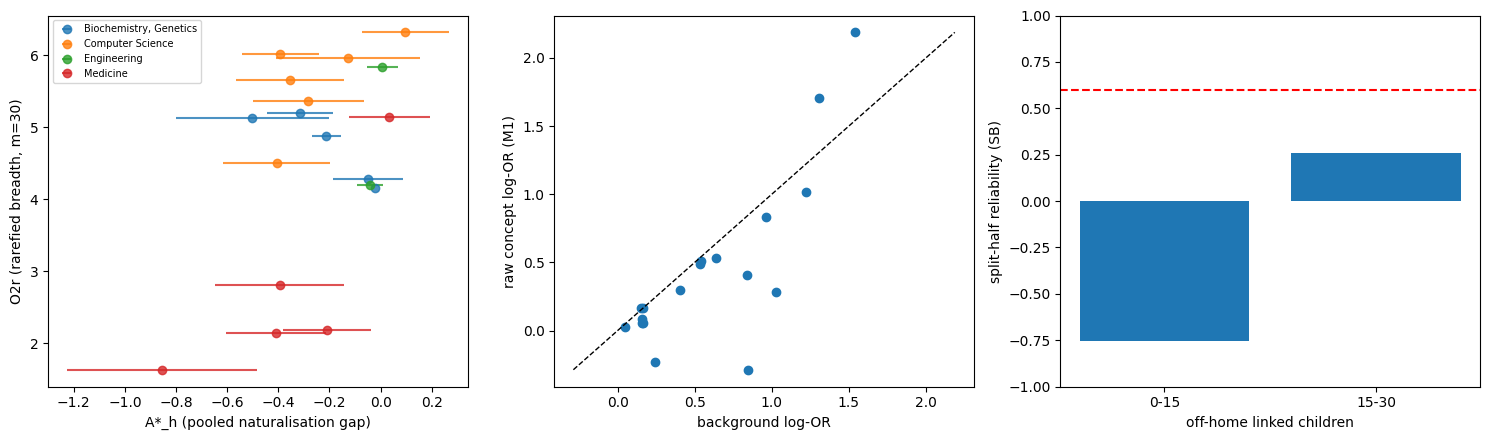

21:15:40|INFO   |SURVIVES=False clauses={'delta_rho_ge_0.10_and_ci_low_gt_0': False, 'positive_groups_ge_3_of_4': False, 'reliability_ge_0.6': True, 'size_abs_rho_le_0.6': True} runtime 104s


In [26]:
# ---------------- outputs
D["oof_B5"] = main_cmp["oof_B"]; D["oof_B5_plus_A_h"] = main_cmp["oof_BC"]
credits = pd.DataFrame({"credits": data["credits"]})  # notebook: OpenAlex credit ledger column (was logs/credits.csv)
deviations = [
    "D1 (plan): availability-cancelling MH table with home children as the control row, not the literal off-home-only GLMM (T0 test ii demonstrates the drift).",
    "D2 (plan): two-stage crossed random-effects pooling (REML-EB via Henderson MME) with PyMC NUTS and a one-stage BinomialBayesMixedGLM as checks.",
    "D8 (new, credit-bound): the shared OpenAlex daily pool (10,000 credits, five artifacts) was at 2,098 at start and fell below the 1,000-credit sibling floor after 139 own credits; OpenAlex S0 is complete only for yearly counts (all 78 concepts) and for field distributions of 11 dev concepts (OpenAlex topic fields). The count-based parts of S0 (t0, newborn, O1, O3, log early volume, early growth) follow S0 exactly.",
    "D9 (new, zero-credit data): concept papers (title/abstract phrase search), their citation lists (lineage links) and field labels come from the Semantic Scholar Graph API. Field labels are fractional memberships over the 23 S2 fields of study (s2-fos-model, a title/abstract text classifier, hence not circular for citation flows) instead of 26-field OpenAlex venue labels; home, dev restriction (sealed = home outside CS/Engineering/Biology/Medicine), O2r, R_j and the field-based B5 terms are computed on these S2 labels for every dev concept, and cross-validated against the OpenAlex S0 where it exists.",
    "D10 (new): background references come from FREE OpenAlex singleton GETs (/works/W<MAG>, cost 0 verified from response headers; the client aborts if a singleton is ever charged) and their fields from S2 via MAG ids.",
    "D4' (plan D4 adapted): all phrase-matched early papers are downloaded (up to 25,000); citation lists are pulled for a seeded uniform sample of at most 1,500 parents per concept (parent_thin), which thins links linearly and cancels in the odds ratios.",
    "D3' (plan D3): local exact/lemma confirmation runs on title + abstract; S2 elides most abstracts, so papers whose abstract is elided and whose title lacks the phrase are kept as 'unverifiable' (S2 phrase index) and only papers with an available abstract lacking the phrase are rejected; exact_share = confirmed/(confirmed+rejected).",
    "D12: O3 = peak count in t0+3..t0+8 >= 2 x mean(t0+7, t0+8) (argmax taken over that range, as in the plan).",
]
screen_result = {
    "candidate": "L_naturalisation_gap", "n_used": int(len(D)), "n_dev_concepts": len(names),
    "n_dropped_by_reason": dr["reason"].str.split(":").str[0].str.split(" ").str[0].value_counts().to_dict() if len(dr) else {},
    "delta_rho": main_cmp["delta"], "ci90": main_cmp["ci90"], "rho_B": main_cmp["metric_B"], "rho_BC": main_cmp["metric_BC"],
    "refit_bootstrap": main_cmp["refit_bootstrap"], "per_group": main_cmp["per_group"],
    "n_pos_groups": main_cmp["n_pos_groups"], "reliability": rel, "reliability_vs_n": rel_n,
    "eligibility_threshold": elig_floor, "eligible_subset_result": sub_results.get("eligible"),
    "sensitivity": {"newborn_only": sub_results.get("newborn_only"), "full_parent_sample": sub_results.get("full_parent_sample"),
                    "O2r_m50": sens_m.get("O2r_m50"), "O2r_m20": sens_m.get("O2r_m20"),
                    "B5_plus_offhome_vol_growth": {k: v for k, v in size_adj.items() if not k.startswith("oof")}},
    "size_corr": size,
    "delta_auc_O1": {k: v for k, v in res_auc["O1"].items() if not k.startswith("oof")},
    "delta_auc_O3": {k: v for k, v in res_auc["O3"].items() if not k.startswith("oof")},
    "outcome_prevalence": {"O1": float(D["O1"].mean()), "O3": float(D["O3"].mean()), "n": int(len(D))},
    "hurdle": {k: v for k, v in hurdle.items() if not k.startswith("oof")} if hurdle else "single class (all N_late >= 30)",
    "field_level": field_level, "M1": M1, "agreement": agree, "s0_cross_source": xval,
    "pooling": {"engine": fit.engine, "tau_c": fit.tau_c, "tau_cj": fit.tau_cj, "beta": dict(zip(fit.fields_x, fit.beta)),
                "n_cells": len(units)},
    "pymc_check": pymc_check, "glmm_check": glmm,
    "survives": survives, "clause_results": clauses, "secondary_rules_exploratory": secondary_rules,
    "candidate_comparison_table": cand_table,
    "credits_used": int(credits["credits"].sum()), "openalex_calls": int(len(credits)),
    "runtime_s": time.time() - t_start, "deviations": deviations,
}
screen_result = jsonable(screen_result)
out.drop(columns=[]).to_csv(RES / "outcomes.csv", index=False)
if len(oa_rows):
    oa_rows.drop(columns=["yc"]).to_csv(RES / "outcomes_openalex_s0.csv", index=False)
fo.to_csv(RES / "field_outcomes.csv", index=False)
feat.to_csv(RES / "features.csv", index=False)
ff.to_csv(RES / "field_features.csv", index=False)
dr.to_csv(RES / "dropped.csv", index=False)
D.to_csv(RES / "screen_table.csv", index=False)
(RES / "screen_result.json").write_text(json.dumps(screen_result, indent=1))
write_method_out(D, FL, screen_result)
try:
    figures(D, feat, rel_n)
except Exception as e:
    logger.error(f"figures failed: {e!r}")
logger.info(f"SURVIVES={survives} clauses={ {k: v['pass'] for k, v in clauses.items()} } "
            f"runtime {time.time()-t_start:.0f}s")

## Results summary

The table below sets the demo's key statistics beside the reference values from the original full 48-concept run.
The plots show out-of-fold predictions and the exploratory candidate comparison.

                        statistic demo (this run) full run (48 concepts)
              n dev concepts used              18                     48
       rho_B5 (LOGO OOF Spearman)           0.874                  0.834
                      rho_B5+A*_h           0.907                  0.828
                        Delta-rho           0.033                 -0.006
             Delta-rho 90% CI low          -0.019                 -0.034
            Delta-rho 90% CI high           0.139                  0.017
         positive left-out groups               2                      0
reliability A*_h (Spearman-Brown)           0.673                  0.584
      |rho| with log early volume           0.356                  0.145
          |rho| with early growth           0.154                  0.177
                     O1 Delta-AUC          -0.014                 -0.026
      field-level Delta-AUC (R_j)           0.016                  0.002
M1 R^2 (raw vs background log-OR)           0.638  

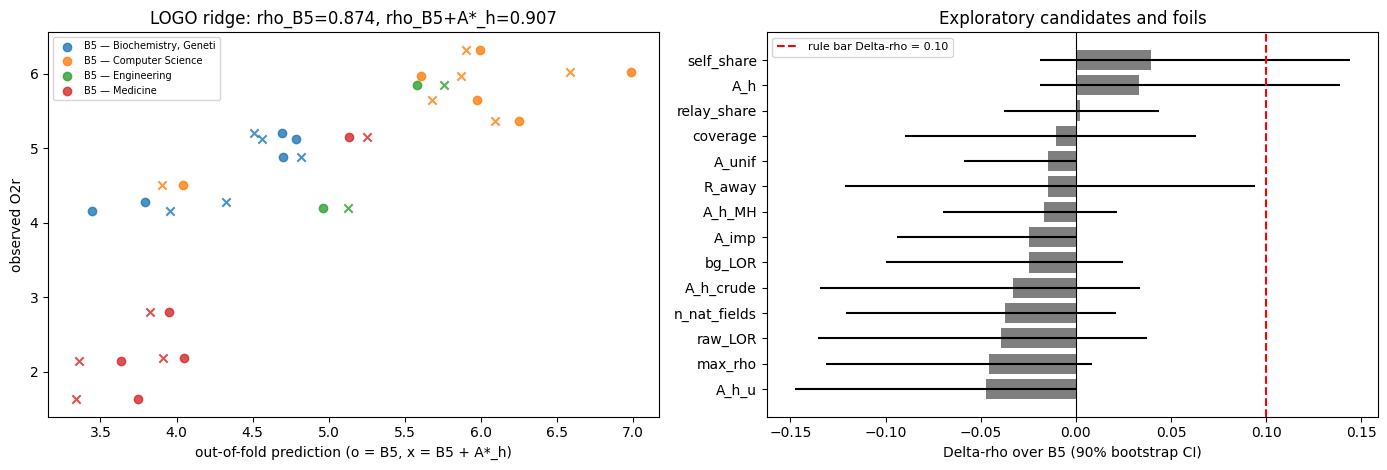

In [27]:
ref = data["reference_full_run"]
rows = [("n dev concepts used", screen_result["n_used"], ref["n_used"]),
        ("rho_B5 (LOGO OOF Spearman)", screen_result["rho_B"], ref["rho_B"]),
        ("rho_B5+A*_h", screen_result["rho_BC"], ref["rho_BC"]),
        ("Delta-rho", screen_result["delta_rho"], ref["delta_rho"]),
        ("Delta-rho 90% CI low", screen_result["ci90"][0], ref["ci90"][0]),
        ("Delta-rho 90% CI high", screen_result["ci90"][1], ref["ci90"][1]),
        ("positive left-out groups", screen_result["n_pos_groups"], ref["n_pos_groups"]),
        ("reliability A*_h (Spearman-Brown)", (screen_result["reliability"].get("A_h") or {}).get("reliability_SB"),
         ref["reliability_A_h_SB"]),
        ("|rho| with log early volume", abs(screen_result["size_corr"]["vol"]), abs(ref["size_corr"]["vol"])),
        ("|rho| with early growth", abs(screen_result["size_corr"]["growth"]), abs(ref["size_corr"]["growth"])),
        ("O1 Delta-AUC", screen_result["delta_auc_O1"]["delta"], ref["delta_auc_O1"]),
        ("field-level Delta-AUC (R_j)", (screen_result["field_level"] or {}).get("delta"), ref["field_level_delta"]),
        ("M1 R^2 (raw vs background log-OR)", (screen_result["M1"] or {}).get("R2"), ref["M1_R2"]),
        ("REML tau_c", screen_result["pooling"]["tau_c"], ref["tau_c"]),
        ("REML tau_cj", screen_result["pooling"]["tau_cj"], ref["tau_cj"]),
        ("SURVIVES pre-registered rule", screen_result["survives"], ref["survives"])]
summary = pd.DataFrame(rows, columns=["statistic", "demo (this run)", "full run (48 concepts)"])
pd.set_option("display.width", 140)
print(summary.to_string(index=False, float_format=lambda x: f"{x:.3f}"))
print("\nClause results (demo):")
for k, v in screen_result["clause_results"].items():
    print(f"  {k:<40} pass={v['pass']}  value={v['value']}")
print("\nPer-group Delta-rho (demo):")
for g, v in screen_result["per_group"].items():
    print(f"  {g:<45} n={v['n']:>2}  delta={v['delta'] if v['delta'] is not None else float('nan'):+.3f}  sign={v['sign']}")

fig, ax = plt.subplots(1, 2, figsize=(14, 4.8))
for g, s_ in D.groupby("dev_group"):
    ax[0].scatter(s_["oof_B5"], s_["O2r"], marker="o", label=f"B5 — {g[:20]}", alpha=.8)
    ax[0].scatter(s_["oof_B5_plus_A_h"], s_["O2r"], marker="x", color=ax[0].collections[-1].get_facecolor()[0], alpha=.8)
ax[0].set_xlabel("out-of-fold prediction (o = B5, x = B5 + A*_h)"); ax[0].set_ylabel("observed O2r")
ax[0].set_title(f"LOGO ridge: rho_B5={screen_result['rho_B']:.3f}, rho_B5+A*_h={screen_result['rho_BC']:.3f}")
ax[0].legend(fontsize=7)
ct = pd.DataFrame({k: {"delta": v["delta_rho"], "lo": v["ci90"][0], "hi": v["ci90"][1]}
                   for k, v in screen_result["candidate_comparison_table"].items()}).T.sort_values("delta")
ax[1].barh(ct.index, ct["delta"], xerr=[ct["delta"] - ct["lo"], ct["hi"] - ct["delta"]], color="tab:gray")
ax[1].axvline(0.10, color="r", ls="--", label="rule bar Delta-rho = 0.10"); ax[1].axvline(0, color="k", lw=.8)
ax[1].set_xlabel("Delta-rho over B5 (90% bootstrap CI)"); ax[1].set_title("Exploratory candidates and foils")
ax[1].legend(fontsize=8)
fig.tight_layout(); plt.show()